# Prepare OND prediction dataset with preceding JJAS features

This notebook builds a dataset for predicting OND seasonal rainfall using:
- past OND values (sliding window lookback), and
- the JJAS seasonal total from the same year as an additional predictor.

The following cells define the dataset-prep class, train three models (KNN, ELM, ANN),
and produce time-series and spatial visualizations comparing predictions to observations.

In [8]:
# Dataset preparation class with detailed comments
class ONDDatasetPreparation:
    """Prepare OND prediction samples including preceding JJAS values."""

    def __init__(self):
        # A MinMaxScaler instance used to normalize the OND target series when
        # constructing sliding-window features. We keep it as an attribute so
        # inverse-transform can be applied later if needed.
        self.scaler = MinMaxScaler()

    def prepare_train_test_data(self, ond_df: pd.DataFrame, jjas_df: pd.DataFrame,
                                ond_target_col='OND_SUM', jjas_col='JJAS_SUM',
                                lookback=3, split_year=2010) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, pd.DataFrame]:
        """Build samples and metadata for training and testing.
        - `ond_df` and `jjas_df` must contain columns: `YEAR`, `LATITUDE`, `LONGITUDE`, and the respective sum columns.
        - For each station (lat,lon) we form samples: [OND_t-3, OND_t-2, OND_t-1, JJAS_t] -> predict OND_t.
        - Returns `(x_train, x_test, y_train, y_test, y_test_meta)` where `x` has shape (n, lookback+1)."""

        # Merge JJAS totals into the OND table so each OND row has the JJAS of the same year/station
        merged = pd.merge(ond_df, jjas_df[[ 'YEAR', 'LATITUDE', 'LONGITUDE', jjas_col]],
                          on=['YEAR', 'LATITUDE', 'LONGITUDE'], how='left')

        X, y, y_meta = [], [], []

        # Normalize OND target values for numerical stability when creating lookbacks
        merged[f'{ond_target_col}_norm'] = self.scaler.fit_transform(merged[[ond_target_col]])
        # Normalize JJAS separately so it sits on a comparable scale to the OND lookback features
        merged[f'{jjas_col}_norm'] = MinMaxScaler().fit_transform(merged[[jjas_col]])

        grouped = merged.groupby(['LATITUDE', 'LONGITUDE'])

        for _, group in grouped:
            series = group[f'{ond_target_col}_norm'].values
            years = group['YEAR'].values
            lats = group['LATITUDE'].values
            lons = group['LONGITUDE'].values
            jjas_series = group[f'{jjas_col}_norm'].values

            # need at least `lookback + 1` points to create one sample
            if len(series) <= lookback:
                continue

            # sliding-window across the station time-series
            for i in range(len(series) - lookback):
                ond_look = series[i:i+lookback]
                # take JJAS normalized value for the target year aligned with y at i+lookback
                jjas_val = jjas_series[i+lookback]
                feat = np.concatenate([ond_look, [jjas_val]])
                X.append(feat)
                y.append(series[i+lookback])
                y_meta.append({'YEAR': int(years[i+lookback]),
                               'LATITUDE': float(lats[i+lookback]),
                               'LONGITUDE': float(lons[i+lookback])})

        X = np.array(X)
        y = np.array(y)
        y_meta_df = pd.DataFrame(y_meta)

        # Split by YEAR so that past years form the training set and later years the test set
        train_idx = y_meta_df['YEAR'] <= split_year
        test_idx = y_meta_df['YEAR'] > split_year

        x_train, x_test = X[train_idx.values], X[test_idx.values]
        y_train, y_test = y[train_idx.values], y[test_idx.values]
        y_test_meta = y_meta_df[test_idx.values].reset_index(drop=True)

        return x_train, x_test, y_train, y_test, y_test_meta

    def normalizer_inverse_transform_array(self, data):
        "Inverse transform normalized values back to the original OND scale."
        vals = np.array(data).reshape(-1, 1)
        return self.scaler.inverse_transform(vals).flatten()

In [9]:
# Example usage: load CSVs, prepare dataset, and inspect shapes
ond_path = 'data/kerala_ond.csv'
jjas_path = 'data/kerala_jjas.csv'

ond = pd.read_csv(ond_path)
jjas = pd.read_csv(jjas_path)

prep = ONDDatasetPreparation()
x_train, x_test, y_train, y_test, y_test_meta = prep.prepare_train_test_data(
    ond, jjas, lookback=3, split_year=2010
)

print('Prepared OND dataset with JJAS features')
print('x_train shape:', x_train.shape)
print('x_test shape :', x_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape :', y_test.shape)

# Show first few metadata rows for the test set to verify alignment
y_test_meta.head()

Prepared OND dataset with JJAS features
x_train shape: (4922, 4)
x_test shape : (598, 4)
y_train shape: (4922,)
y_test shape : (598,)


,YEAR,LATITUDE,LONGITUDE
0,2011,8.5,77.0
1,2012,8.5,77.0
2,2013,8.5,77.0
3,2014,8.5,77.0
4,2015,8.5,77.0


In [11]:
# Models and evaluation: KNN, ELM, ANN (LM-trained)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
from torch.nn.utils import parameters_to_vector, vector_to_parameters
from dataclasses import dataclass
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from shapely.geometry import box
import geopandas as gpd

# Ensure consistent dtype between model parameters and tensors
torch.set_default_dtype(torch.float64)

# Levenberg–Marquardt trainer and helper functions (adapted)
@dataclass
class LMConfig:
    damping: float = 1.0
    damping_inc: float = 10.0
    damping_dec: float = 10.0
    max_iters: int = 20
    tol: float = 1e-6
    l2: float = 0.0
    verbose: bool = True
    batch_size: int = 0

class LMTrainer:
    def __init__(self, model: nn.Module, config: LMConfig = LMConfig(), device: str = "cpu"):
        self.model = model.to(device)
        self.cfg = config
        self.device = device

    @torch.no_grad()
    def _pack_params(self) -> torch.Tensor:
        return parameters_to_vector([p for p in self.model.parameters()])

    @torch.no_grad()
    def _unpack_params(self, vec: torch.Tensor):
        vector_to_parameters(vec, [p for p in self.model.parameters()])

    def _compute_residuals(self, X: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        preds = self.model(X).reshape(-1)
        return preds - y

    def _compute_jacobian(self, X: torch.Tensor) -> torch.Tensor:
        params = [p for p in self.model.parameters() if p.requires_grad]
        P = sum(p.numel() for p in params)
        N = X.shape[0]
        J = torch.zeros(N, P, dtype=X.dtype, device=X.device)

        for i in range(N):
            self.model.zero_grad(set_to_none=True)
            out = self.model(X[i:i+1]).reshape(())
            out.backward()
            grads = []
            for p in params:
                g = p.grad if p.grad is not None else torch.zeros_like(p)
                grads.append(g.reshape(-1))
            J[i, :] = torch.cat(grads)
        return J

    def fit(self, X: torch.Tensor, y: torch.Tensor):
        X = X.to(self.device)
        y = y.to(self.device)

        lam = self.cfg.damping
        with torch.no_grad():
            r = self._compute_residuals(X, y)
            loss = 0.5 * (r @ r).item()

        if self.cfg.verbose:
            print(f"[LM] init loss = {loss:.6f}, lambda = {lam}")

        for it in range(1, self.cfg.max_iters + 1):
            J = self._compute_jacobian(X)
            with torch.no_grad():
                r = self._compute_residuals(X, y)
                JTJ = J.T @ J
                if self.cfg.l2 > 0:
                    JTJ = JTJ + self.cfg.l2 * torch.eye(JTJ.shape[0], dtype=JTJ.dtype, device=JTJ.device)
                g = J.T @ r

                A = JTJ + lam * torch.eye(JTJ.shape[0], dtype=JTJ.dtype, device=JTJ.device)
                try:
                    delta = torch.linalg.solve(A, -g)
                except RuntimeError:
                    delta = torch.linalg.lstsq(A, -g.unsqueeze(1)).solution.squeeze(1)

                w_old = self._pack_params().clone()
                add_vector_to_parameters(delta, [p for p in self.model.parameters()])

                r_new = self._compute_residuals(X, y)
                loss_new = 0.5 * (r_new @ r_new).item()

                if loss_new < loss:
                    impr = (loss - loss_new) / max(loss, 1e-12)
                    loss = loss_new
                    lam = max(lam / self.cfg.damping_dec, 1e-12)
                    if self.cfg.verbose:
                        print(f"[LM] iter {it:03d} loss={loss:.6f}  accepted λ={lam:.3e} rel_impr={impr:.3e}")
                    if impr < self.cfg.tol:
                        print("[LM] converged.")
                        break
                else:
                    self._unpack_params(w_old)
                    lam = lam * self.cfg.damping_inc
                    if self.cfg.verbose:
                        print(f"[LM] iter {it:03d} loss={loss:.6f}  rejected λ={lam:.3e}")
        return loss

# helper to add delta vector to parameters
def add_vector_to_parameters(vec: torch.Tensor, parameters):
    pointer = 0
    for p in parameters:
        numel = p.numel()
        p.data.add_(vec[pointer:pointer+numel].view_as(p))
        pointer += numel

# ANN definitions
class RadBas(nn.Module):
    def forward(self, x):
        return torch.exp(-(x ** 2))

class ANN_RadBas(nn.Module):
    def __init__(self, input_size=4):
        super().__init__()
        self.hidden = nn.Linear(input_size, 20, bias=True)
        self.radbas = RadBas()
        self.output = nn.Linear(20, 1, bias=True)

    def forward(self, x):
        x = self.hidden(x)
        x = self.radbas(x)
        x = self.output(x)
        return x.squeeze(-1)

# ELM implementation
class ELMRegressor:
    def __init__(self, n_hidden=15, activation='sigmoid', alpha=1e-2, random_state=None):
        self.n_hidden = n_hidden
        self.activation = activation
        self.alpha = alpha
        self.random_state = np.random.RandomState(random_state)

    def _activate(self, X):
        if self.activation == 'sigmoid':
            return 1 / (1 + np.exp(-X))
        elif self.activation == 'tanh':
            return np.tanh(X)
        elif self.activation == 'relu':
            return np.maximum(0, X)
        else:
            return X

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.W = self.random_state.normal(size=(n_features, self.n_hidden))
        self.b = self.random_state.normal(size=(self.n_hidden,))
        H = self._activate(X @ self.W + self.b)
        I = np.identity(self.n_hidden)
        self.beta = np.linalg.pinv(H.T @ H + self.alpha * I) @ H.T @ y

    def predict(self, X):
        H = self._activate(X @ self.W + self.b)
        return H @ self.beta

# --- Train models on the prepared dataset ---
print("Training models on OND+JJAS features...")
# KNN (operates on normalized target values)
knn = KNeighborsRegressor(n_neighbors=5, metric='euclidean', weights="uniform")
knn.fit(x_train, y_train)
y_pred_knn = knn.predict(x_test)

# ELM
elm = ELMRegressor(n_hidden=15, activation='sigmoid', alpha=1e-3, random_state=42)
elm.fit(x_train, y_train)
y_pred_elm = elm.predict(x_test)

# ANN (LM-trained)
torch.manual_seed(42)
X_torch = torch.tensor(x_train, dtype=torch.float64)
y_torch = torch.tensor(y_train, dtype=torch.float64)
model_ann = ANN_RadBas(input_size=x_train.shape[1])
cfg = LMConfig(damping=1.0, max_iters=20, verbose=False)
trainer = LMTrainer(model_ann, cfg, device="cpu")
trainer.fit(X_torch, y_torch)
with torch.no_grad():
    y_pred_ann = model_ann(torch.tensor(x_test, dtype=torch.float64)).numpy()

# Inverse transform predictions to original OND scale
y_true_orig = prep.normalizer_inverse_transform_array(y_test)
y_pred_knn_orig = prep.normalizer_inverse_transform_array(y_pred_knn)
y_pred_elm_orig = prep.normalizer_inverse_transform_array(y_pred_elm)
y_pred_ann_orig = prep.normalizer_inverse_transform_array(y_pred_ann)

# Simple performance printout
print("\nModel Performance (on original scale):")
print("=" * 50)
for name, y_pred in [("KNN", y_pred_knn_orig), ("ELM", y_pred_elm_orig), ("ANN", y_pred_ann_orig)]:
    mae = mean_absolute_error(y_true_orig, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred))
    mae_pct = 100 * mae / np.mean(y_true_orig) if np.mean(y_true_orig) != 0 else 0
    print(f"{name}: MAE={mae:.2f} mm ({mae_pct:.1f}%), RMSE={rmse:.2f} mm")

Training models on OND+JJAS features...

Model Performance (on original scale):
KNN: MAE=196.18 mm (40.6%), RMSE=258.45 mm
ELM: MAE=192.79 mm (39.9%), RMSE=255.64 mm
ANN: MAE=194.78 mm (40.3%), RMSE=256.90 mm


Generating visualizations...


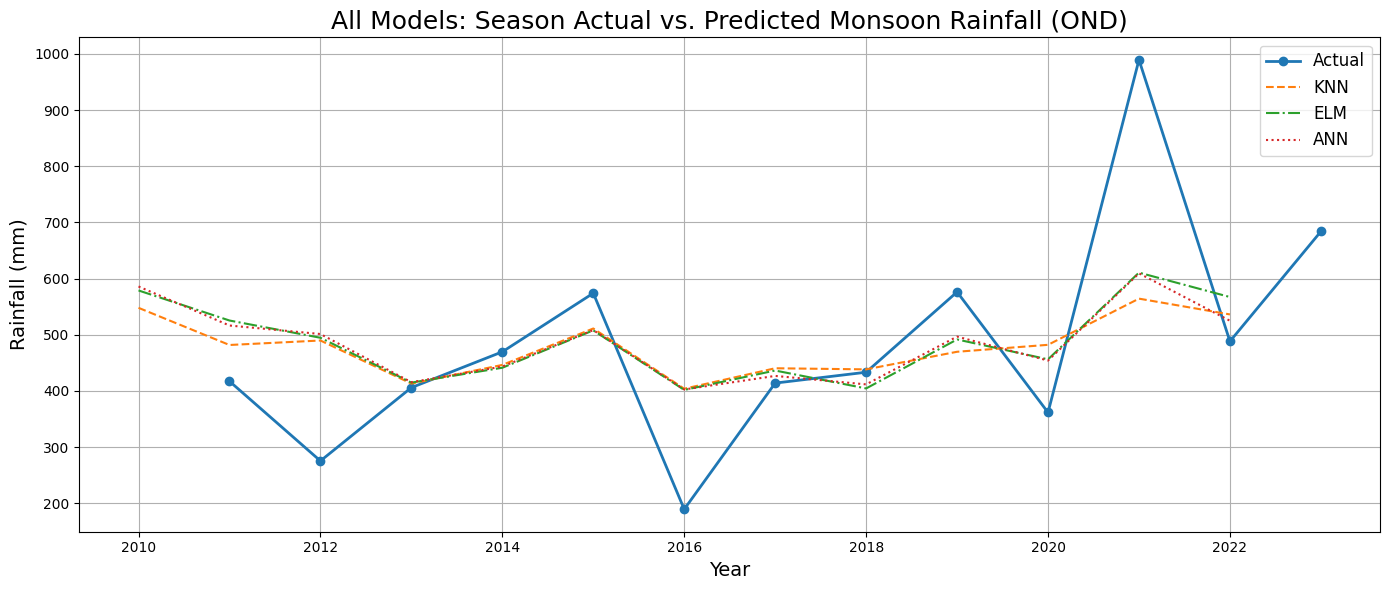

C:\Users\rejoy\AppData\Local\Temp\ipykernel_13944\1818504331.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


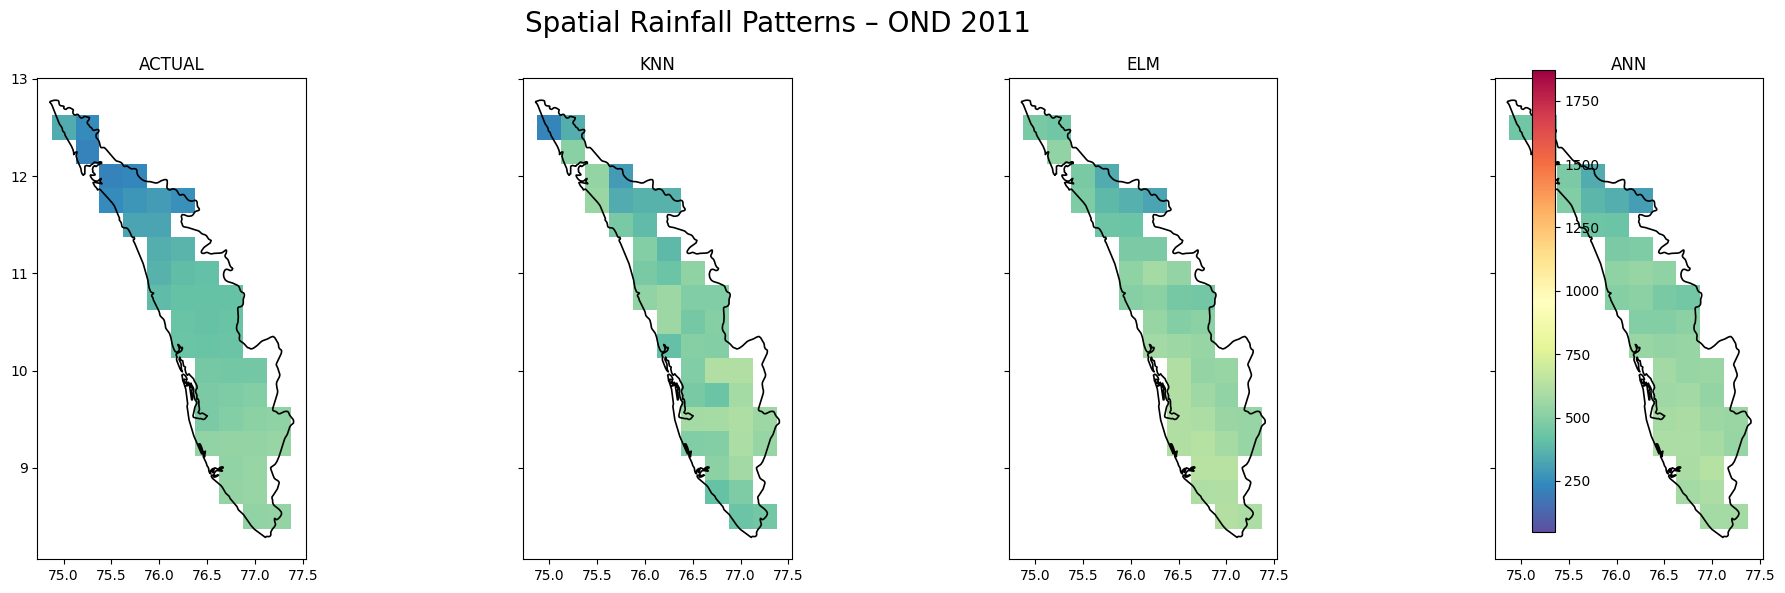

C:\Users\rejoy\AppData\Local\Temp\ipykernel_13944\1818504331.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


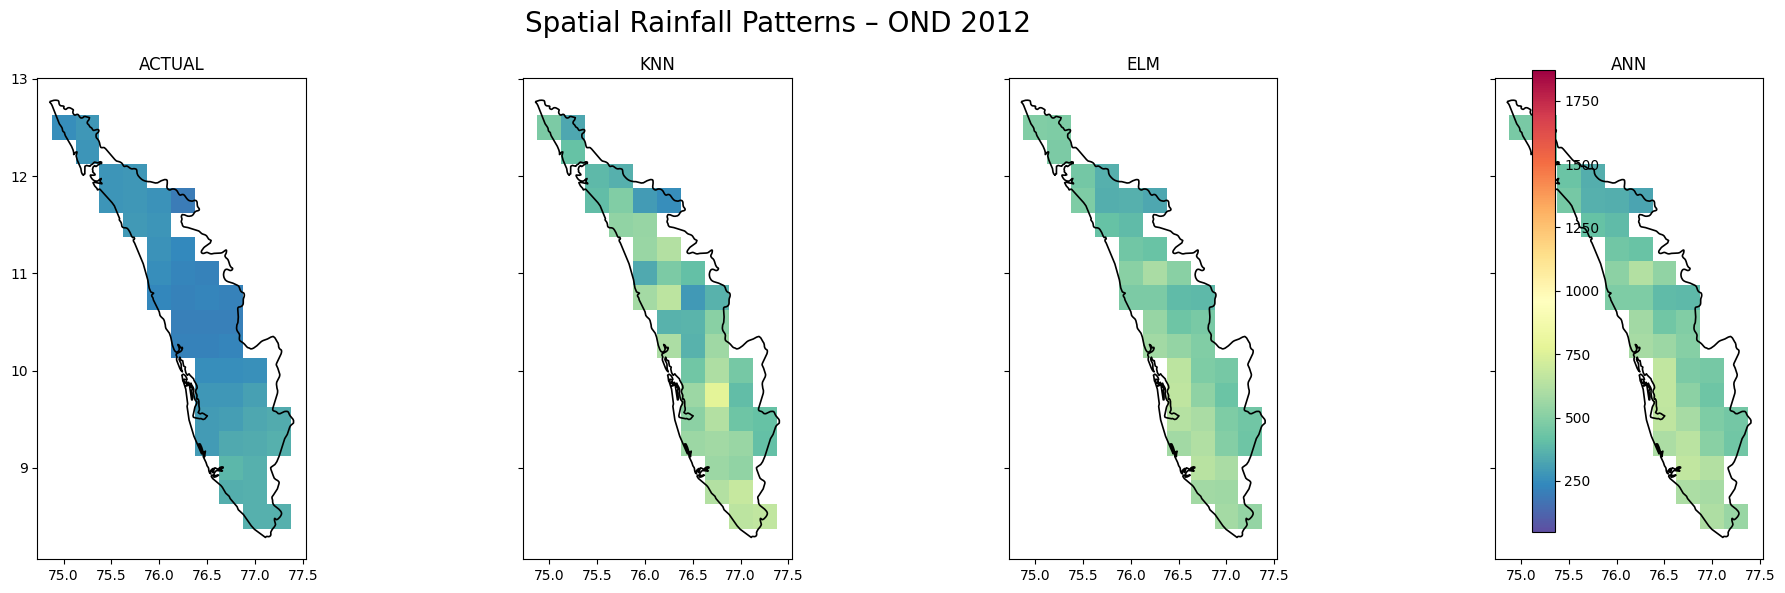

C:\Users\rejoy\AppData\Local\Temp\ipykernel_13944\1818504331.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


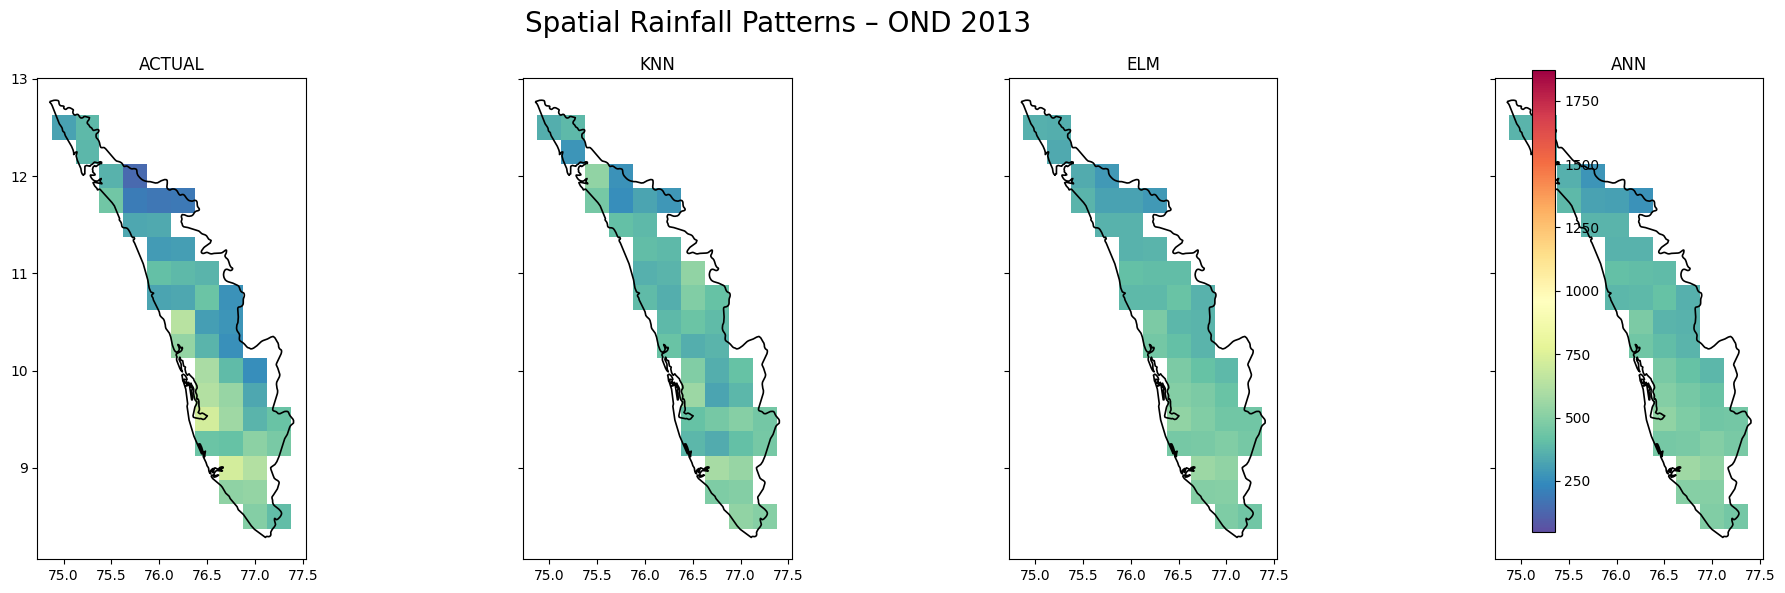

C:\Users\rejoy\AppData\Local\Temp\ipykernel_13944\1818504331.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


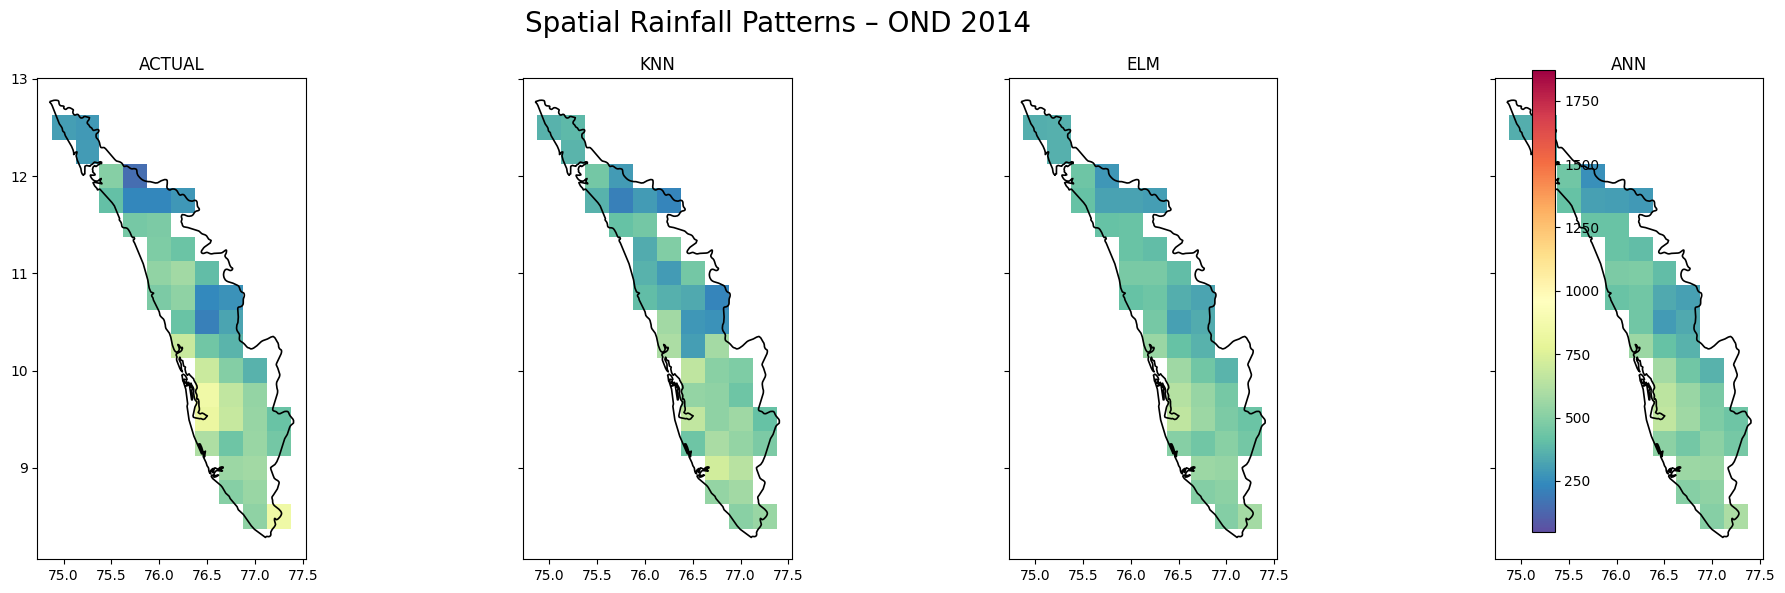

C:\Users\rejoy\AppData\Local\Temp\ipykernel_13944\1818504331.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


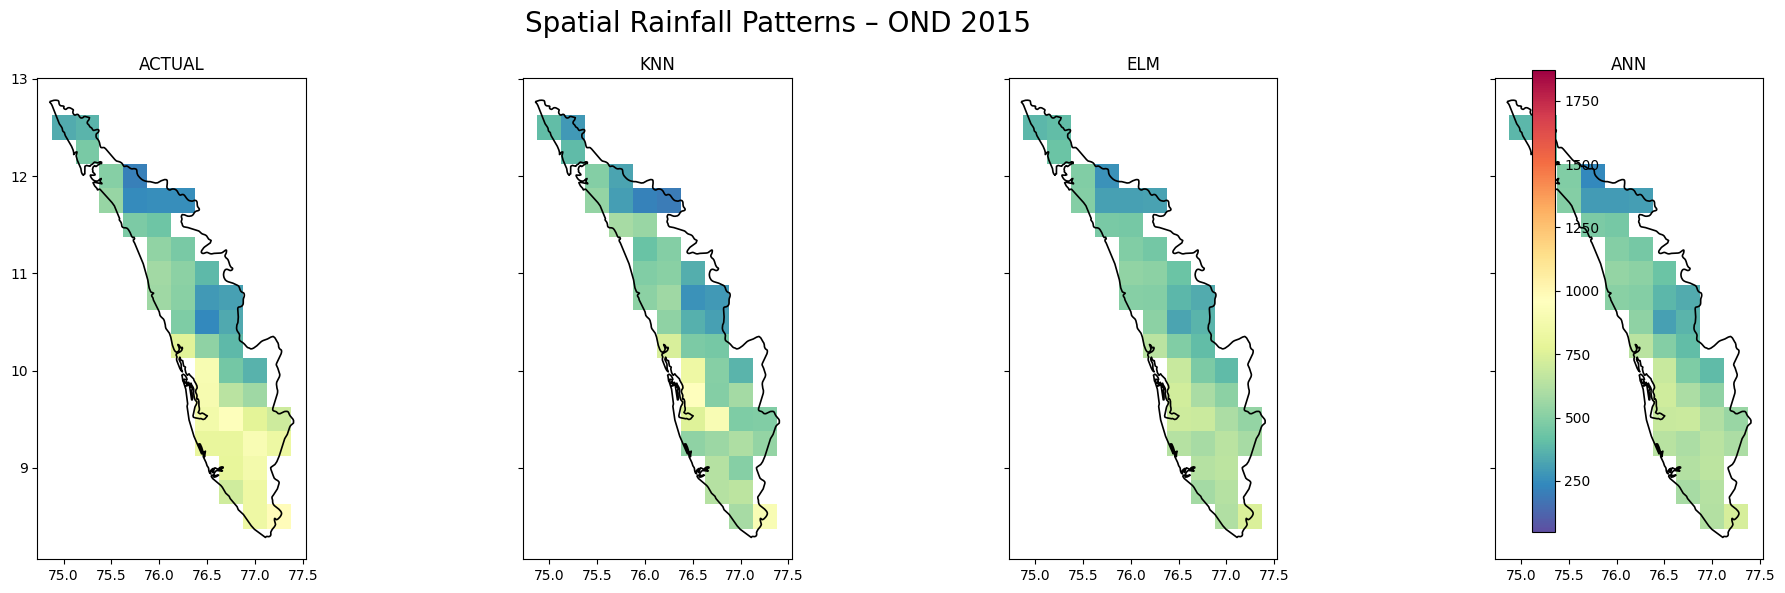

C:\Users\rejoy\AppData\Local\Temp\ipykernel_13944\1818504331.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


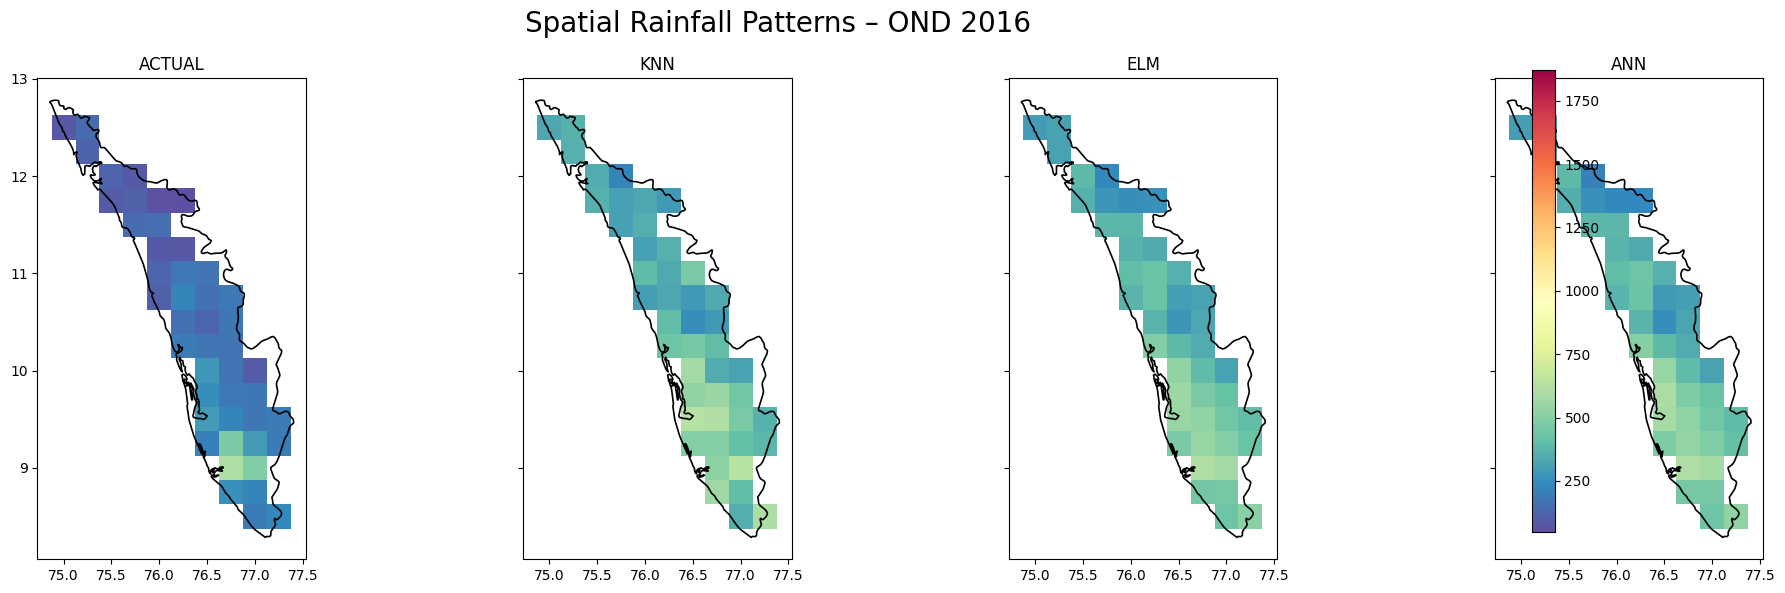

C:\Users\rejoy\AppData\Local\Temp\ipykernel_13944\1818504331.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


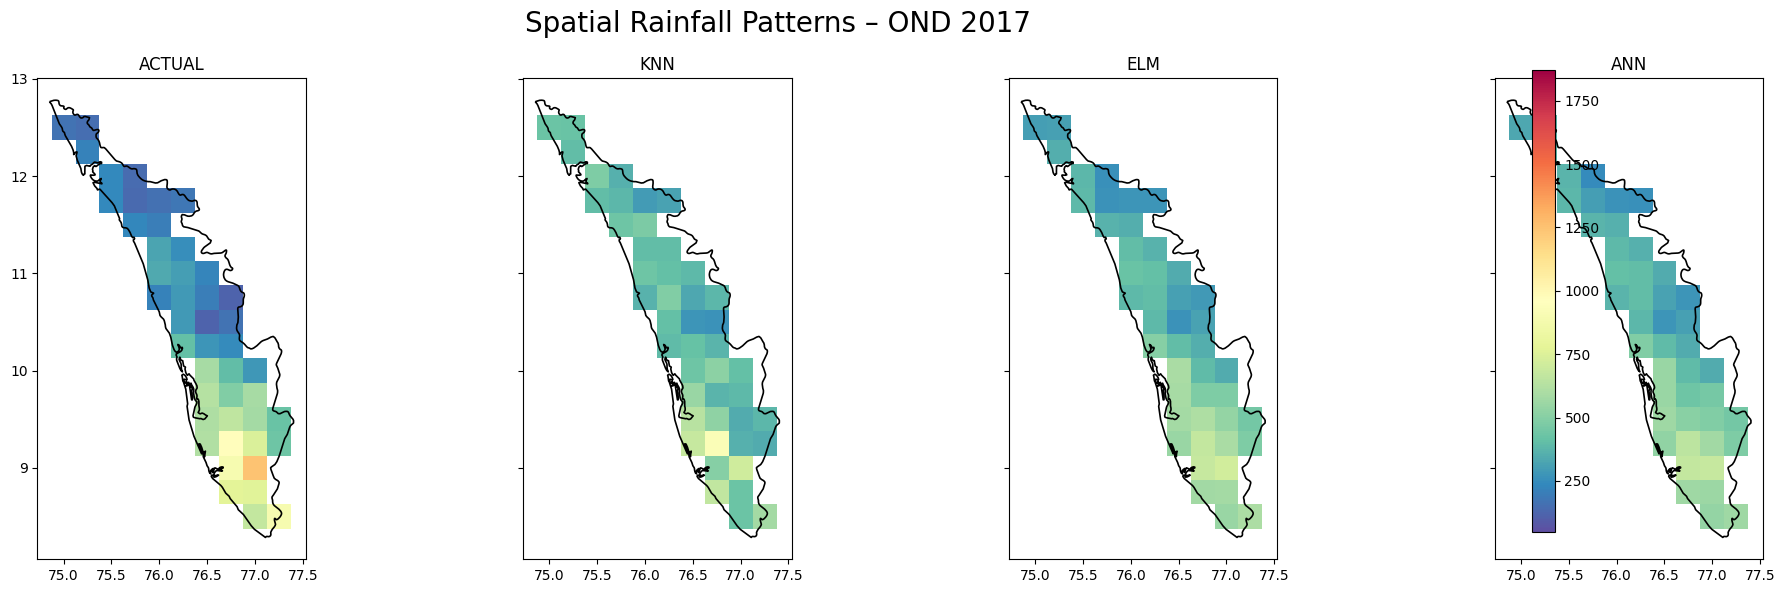

C:\Users\rejoy\AppData\Local\Temp\ipykernel_13944\1818504331.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


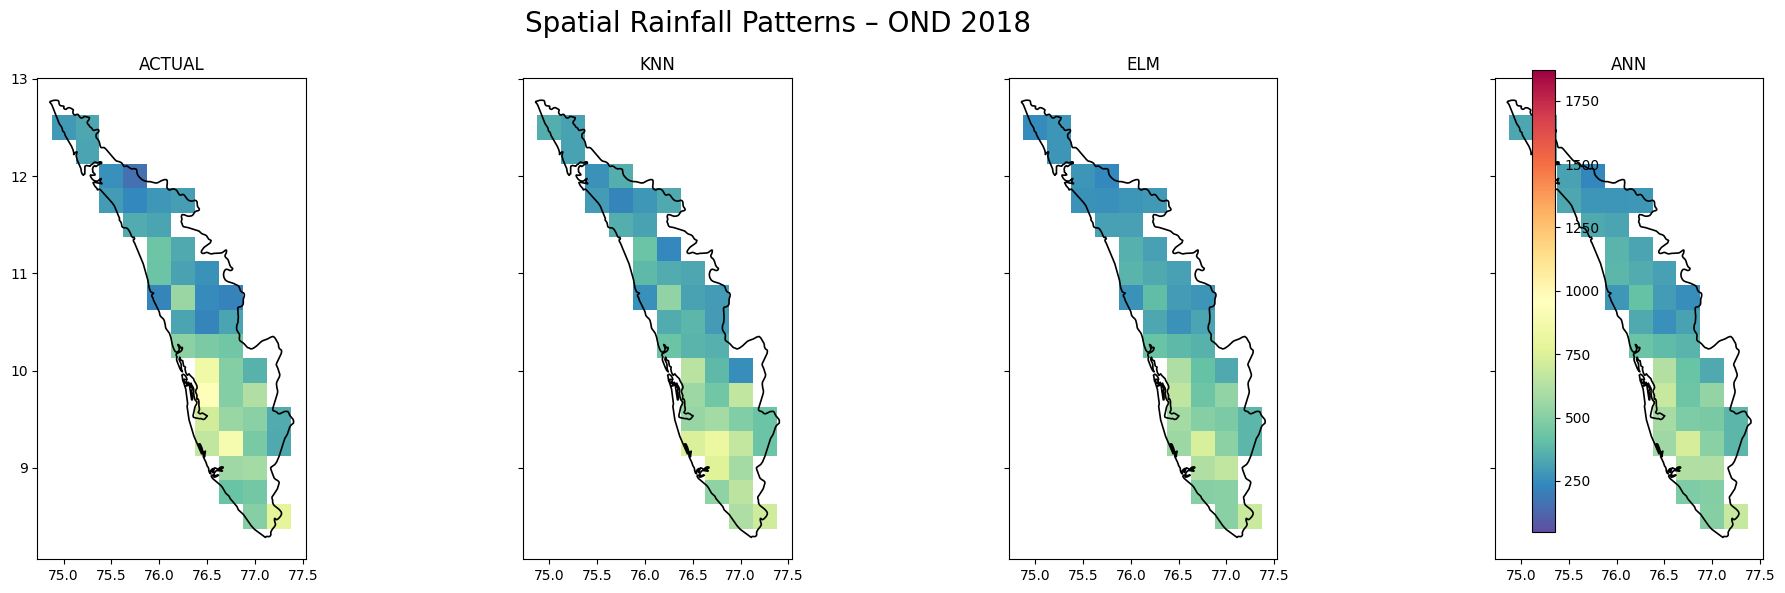

C:\Users\rejoy\AppData\Local\Temp\ipykernel_13944\1818504331.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


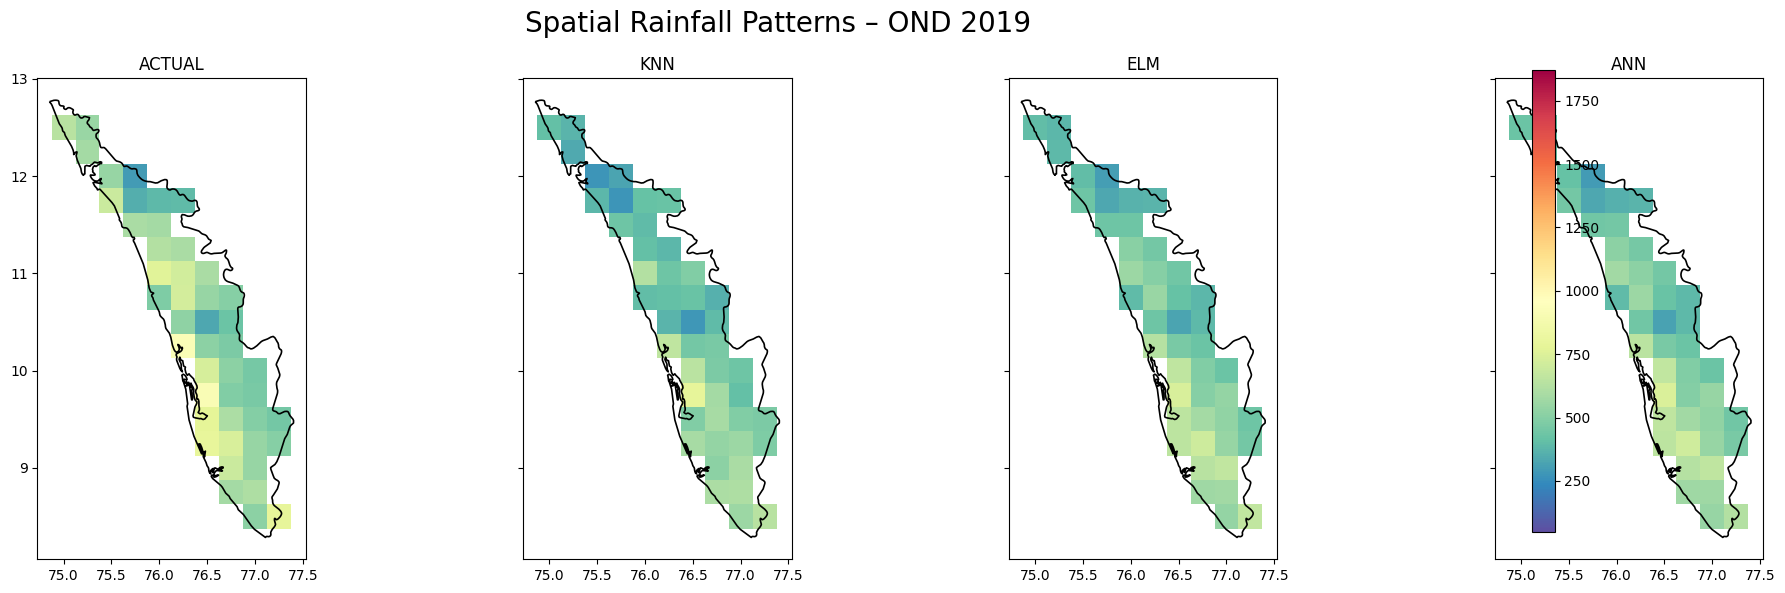

C:\Users\rejoy\AppData\Local\Temp\ipykernel_13944\1818504331.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


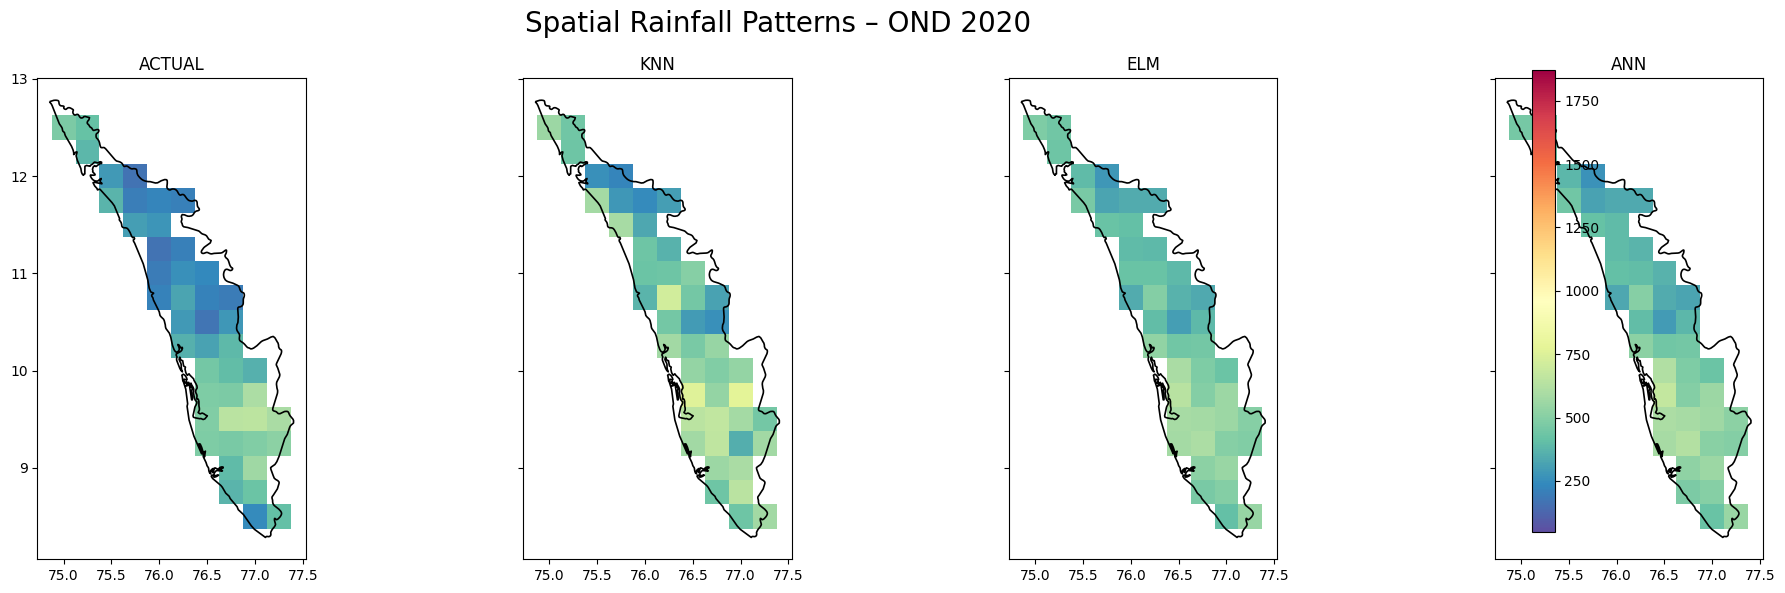

C:\Users\rejoy\AppData\Local\Temp\ipykernel_13944\1818504331.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


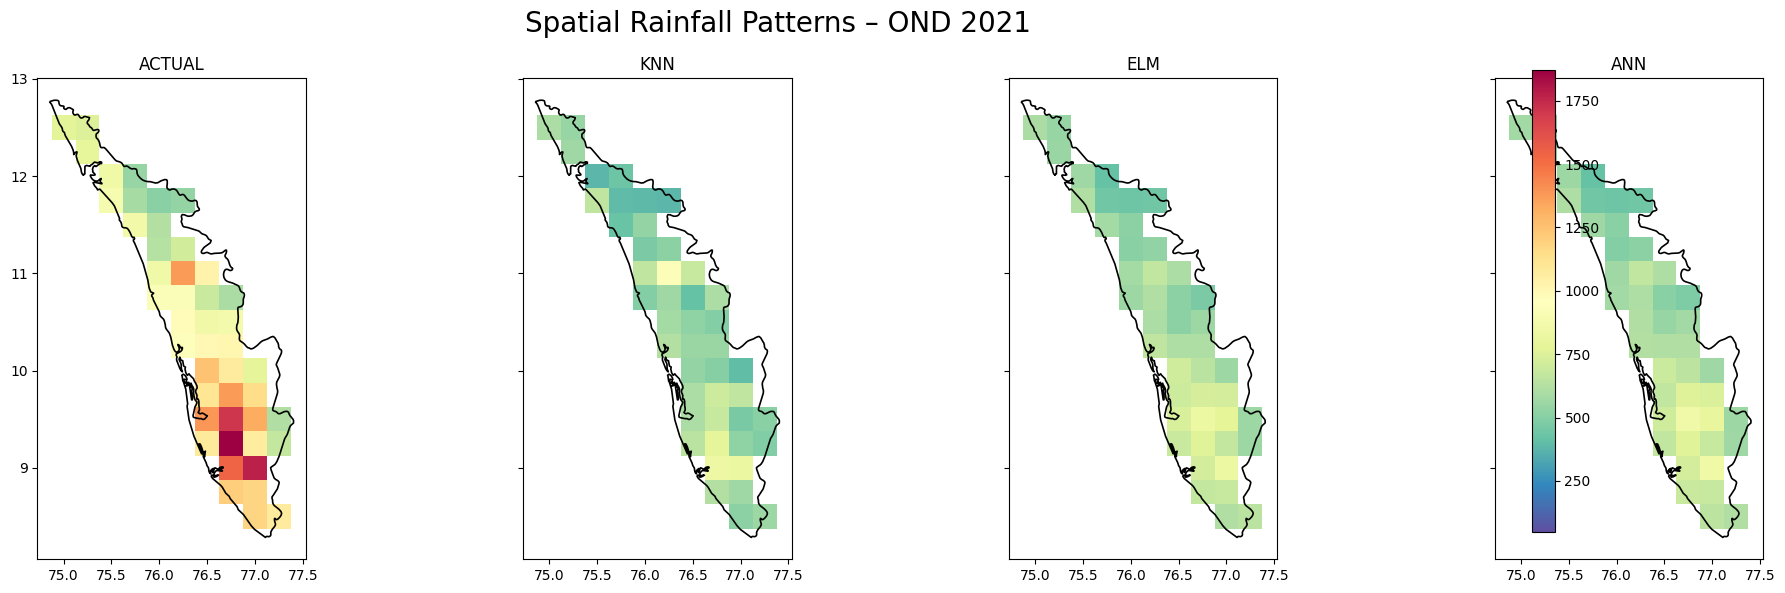

C:\Users\rejoy\AppData\Local\Temp\ipykernel_13944\1818504331.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


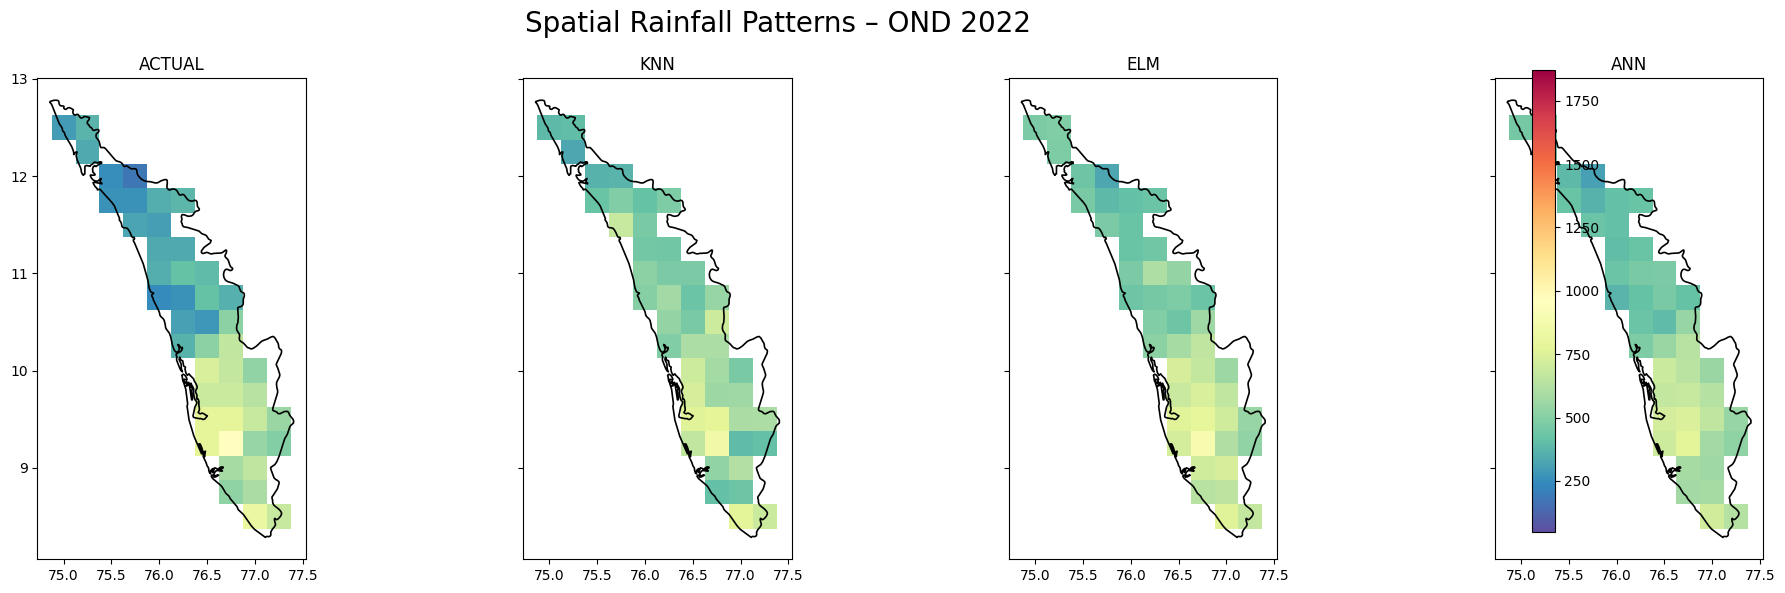


--- Spatial Accuracy Metrics for 2011 ---
  KNN:
    - Mean Absolute Error: 93.40 mm (22.4%)
    - Max Absolute Error:  318.91 mm
  ELM:
    - Mean Absolute Error: 108.13 mm (25.9%)
    - Max Absolute Error:  311.98 mm
  ANN:
    - Mean Absolute Error: 99.22 mm (23.8%)
    - Max Absolute Error:  341.59 mm


C:\Users\rejoy\AppData\Local\Temp\ipykernel_13944\1818504331.py:133: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


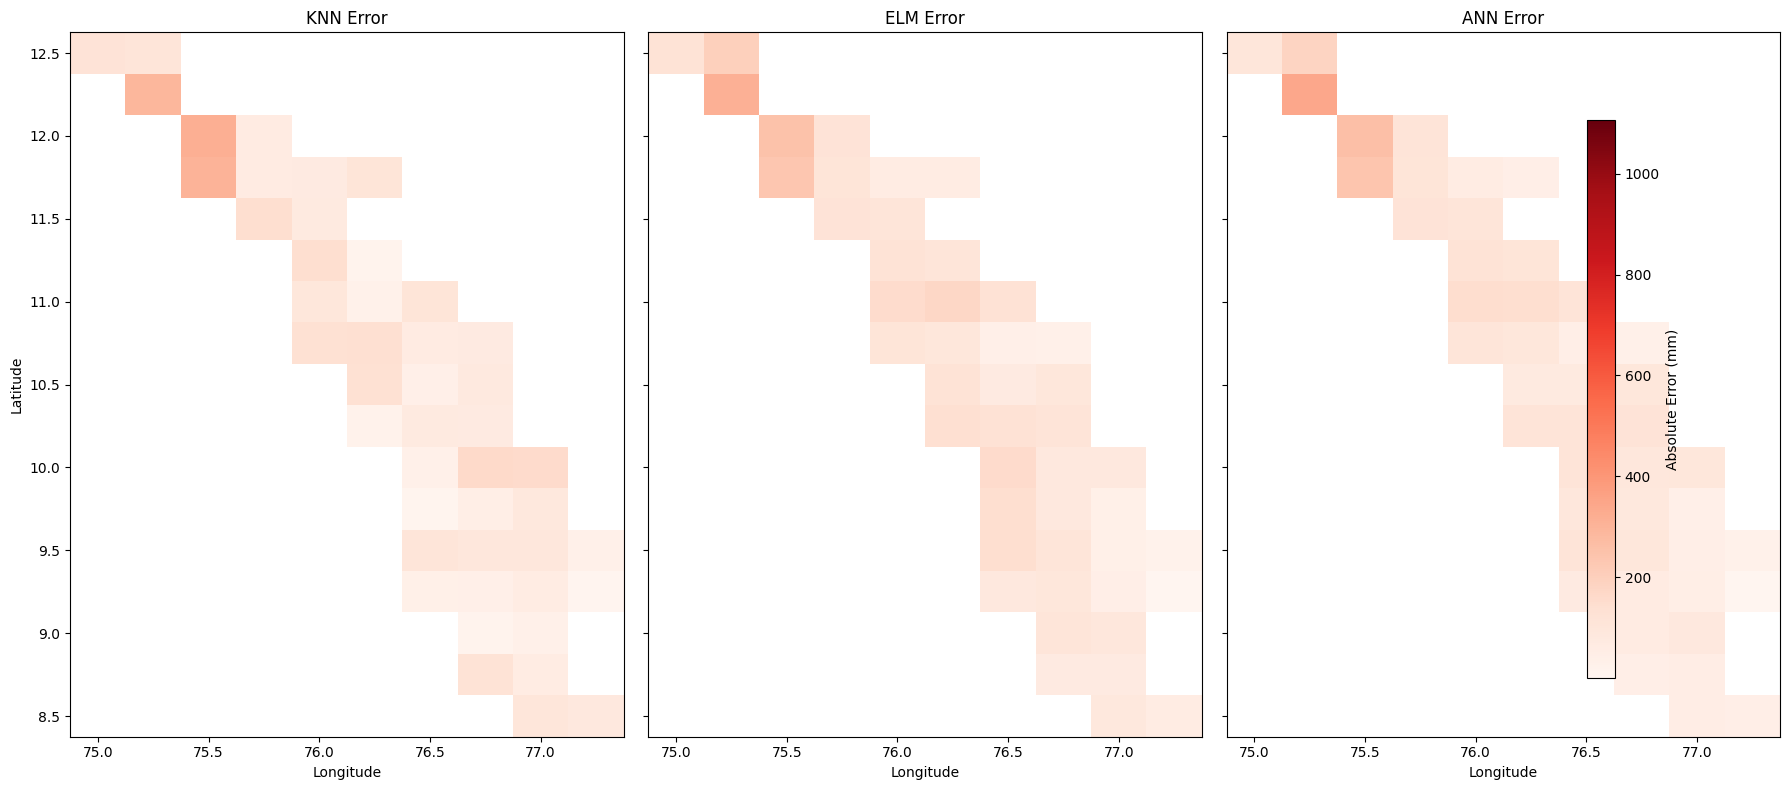


--- Spatial Accuracy Metrics for 2012 ---
  KNN:
    - Mean Absolute Error: 214.39 mm (77.9%)
    - Max Absolute Error:  490.06 mm
  ELM:
    - Mean Absolute Error: 219.27 mm (79.6%)
    - Max Absolute Error:  403.10 mm
  ANN:
    - Mean Absolute Error: 225.94 mm (82.1%)
    - Max Absolute Error:  414.72 mm


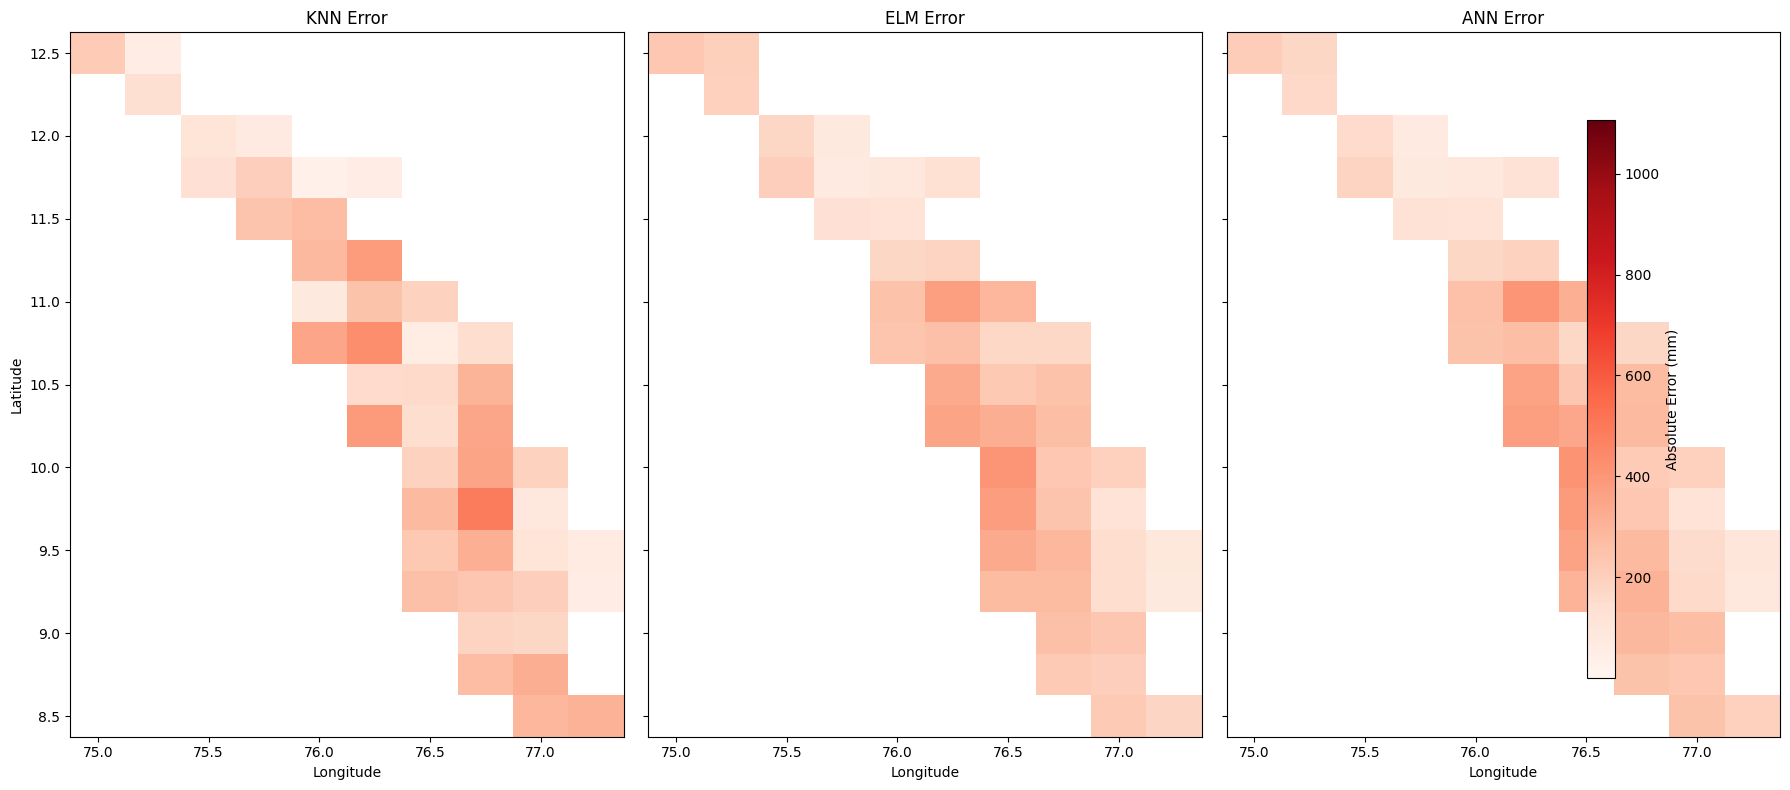


--- Spatial Accuracy Metrics for 2013 ---
  KNN:
    - Mean Absolute Error: 91.78 mm (22.6%)
    - Max Absolute Error:  308.31 mm
  ELM:
    - Mean Absolute Error: 69.49 mm (17.1%)
    - Max Absolute Error:  194.08 mm
  ANN:
    - Mean Absolute Error: 66.57 mm (16.4%)
    - Max Absolute Error:  192.44 mm


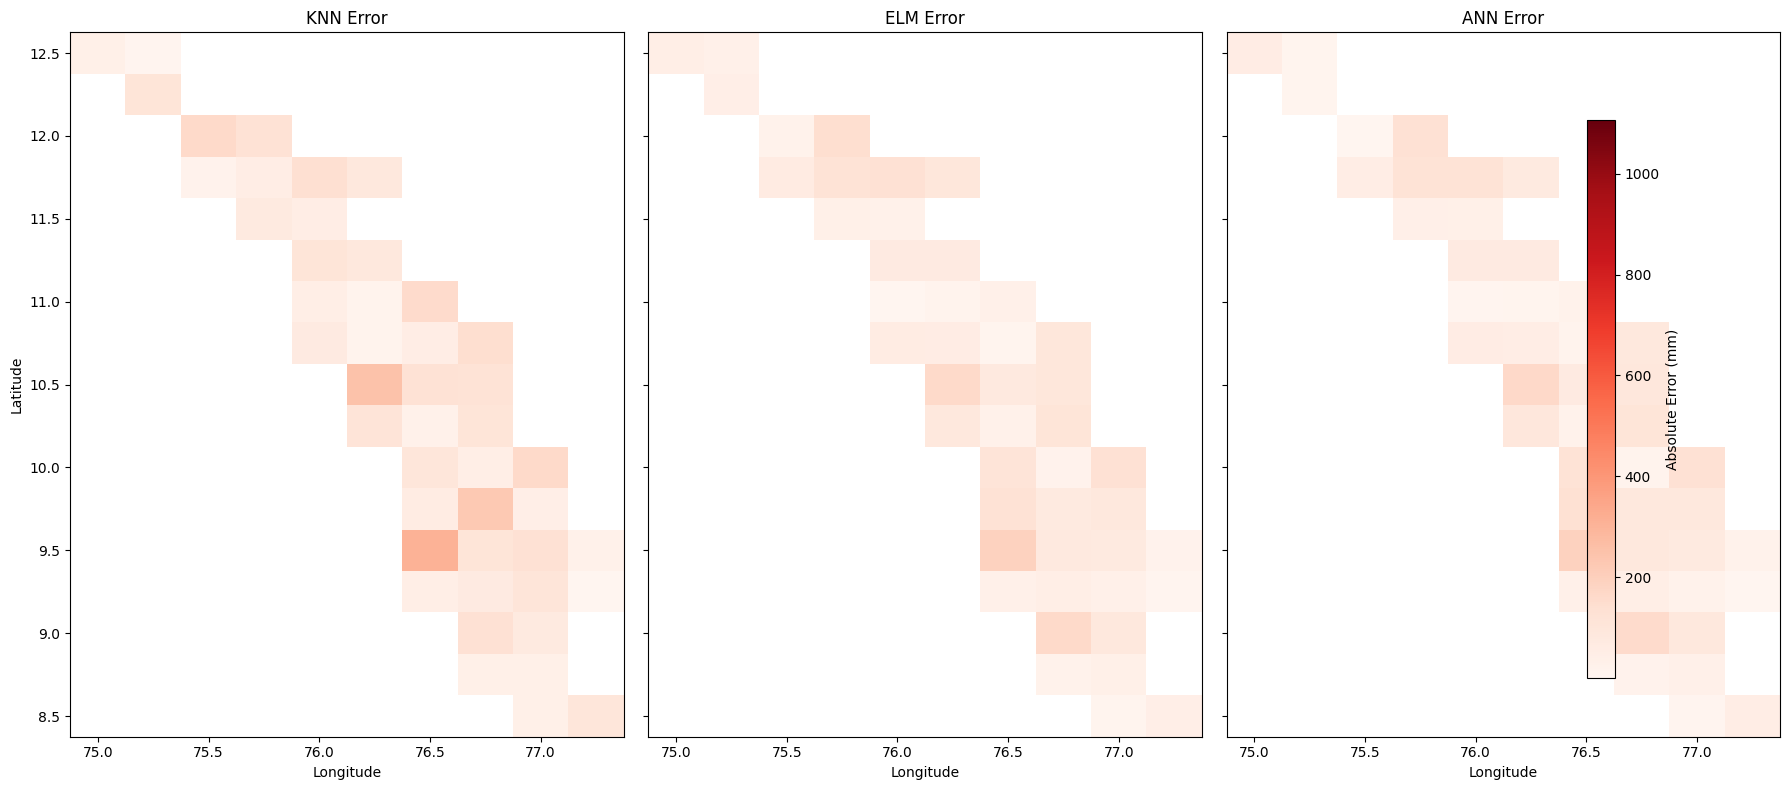


--- Spatial Accuracy Metrics for 2014 ---
  KNN:
    - Mean Absolute Error: 97.36 mm (20.7%)
    - Max Absolute Error:  312.93 mm
  ELM:
    - Mean Absolute Error: 66.54 mm (14.2%)
    - Max Absolute Error:  265.79 mm
  ANN:
    - Mean Absolute Error: 60.19 mm (12.8%)
    - Max Absolute Error:  239.41 mm


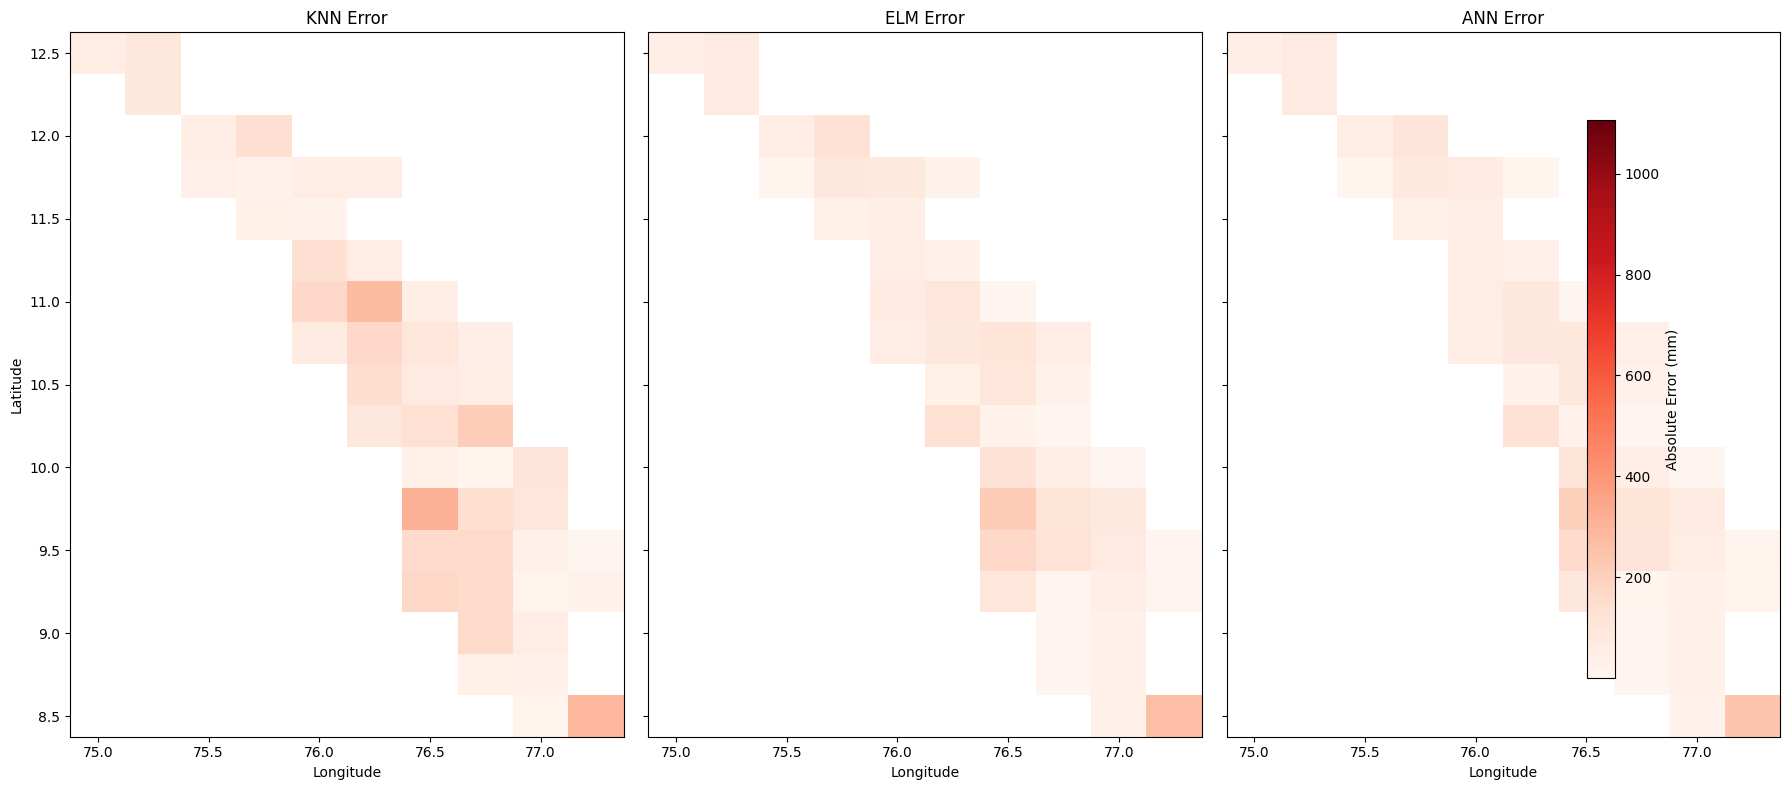


--- Spatial Accuracy Metrics for 2015 ---
  KNN:
    - Mean Absolute Error: 101.87 mm (17.7%)
    - Max Absolute Error:  367.99 mm
  ELM:
    - Mean Absolute Error: 97.21 mm (16.9%)
    - Max Absolute Error:  264.28 mm
  ANN:
    - Mean Absolute Error: 93.47 mm (16.3%)
    - Max Absolute Error:  262.60 mm


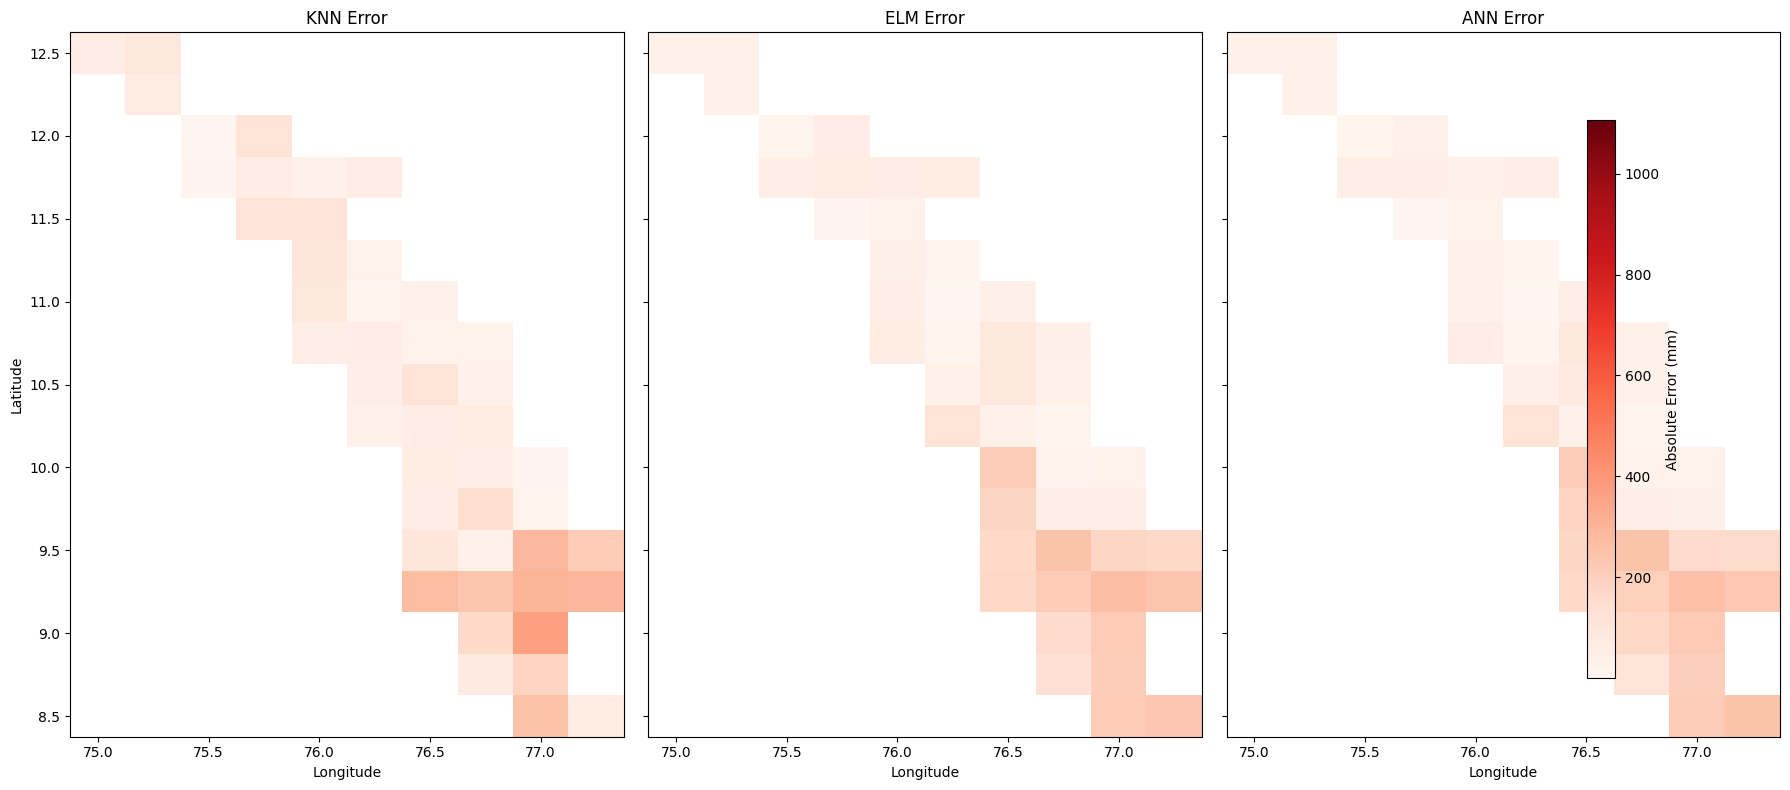


--- Spatial Accuracy Metrics for 2016 ---
  KNN:
    - Mean Absolute Error: 218.47 mm (115.4%)
    - Max Absolute Error:  392.27 mm
  ELM:
    - Mean Absolute Error: 212.40 mm (112.2%)
    - Max Absolute Error:  305.56 mm
  ANN:
    - Mean Absolute Error: 213.24 mm (112.6%)
    - Max Absolute Error:  341.26 mm


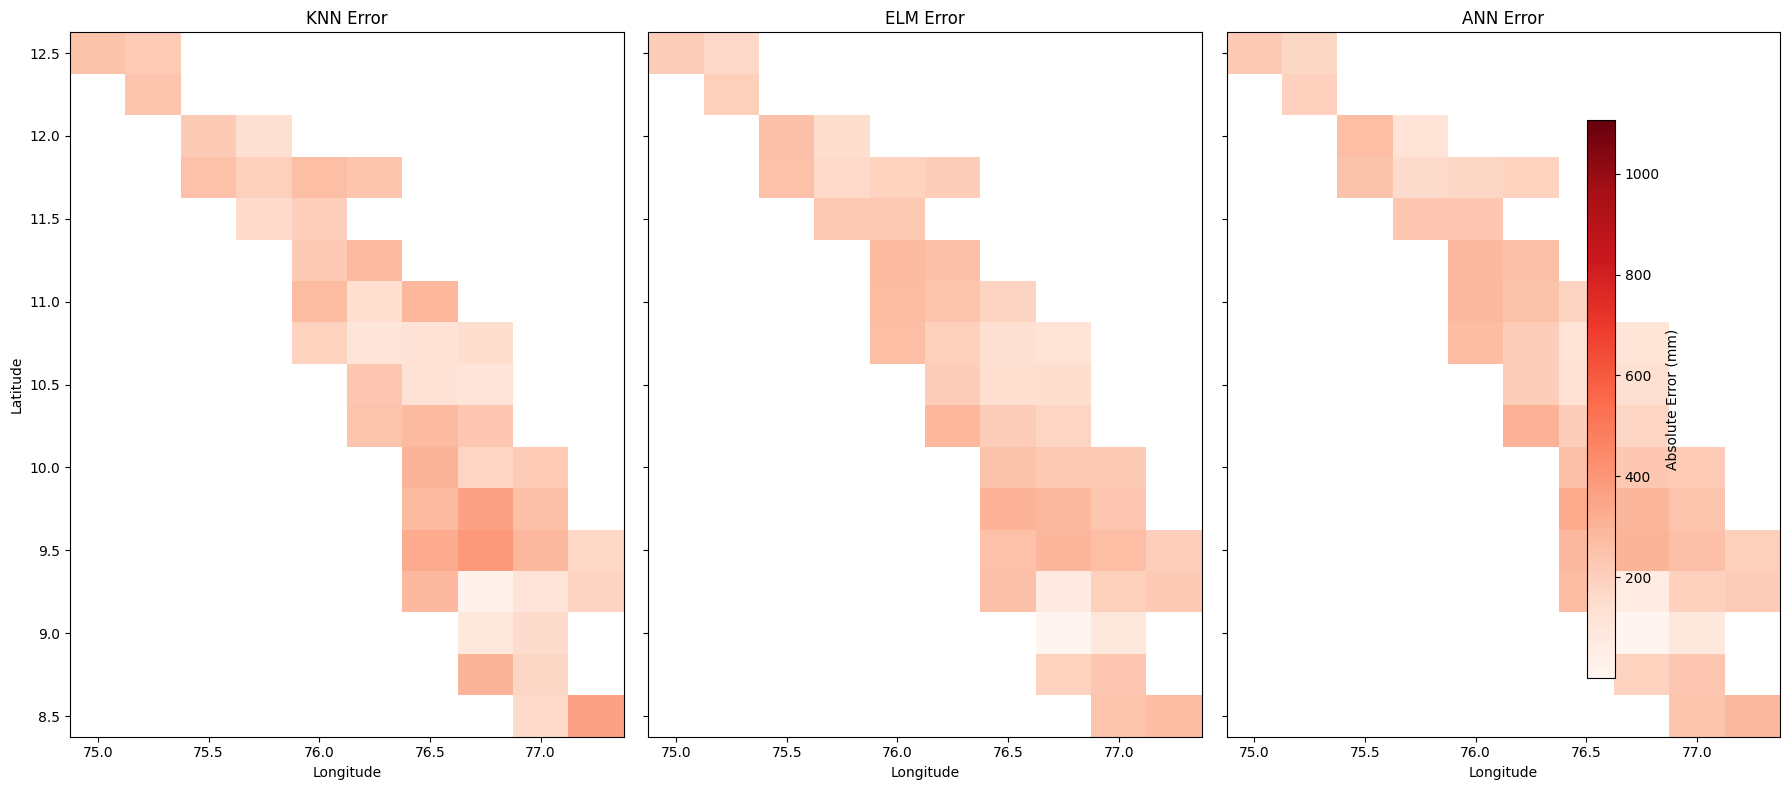


--- Spatial Accuracy Metrics for 2017 ---
  KNN:
    - Mean Absolute Error: 175.86 mm (42.5%)
    - Max Absolute Error:  538.63 mm
  ELM:
    - Mean Absolute Error: 124.74 mm (30.1%)
    - Max Absolute Error:  531.73 mm
  ANN:
    - Mean Absolute Error: 136.58 mm (33.0%)
    - Max Absolute Error:  566.51 mm


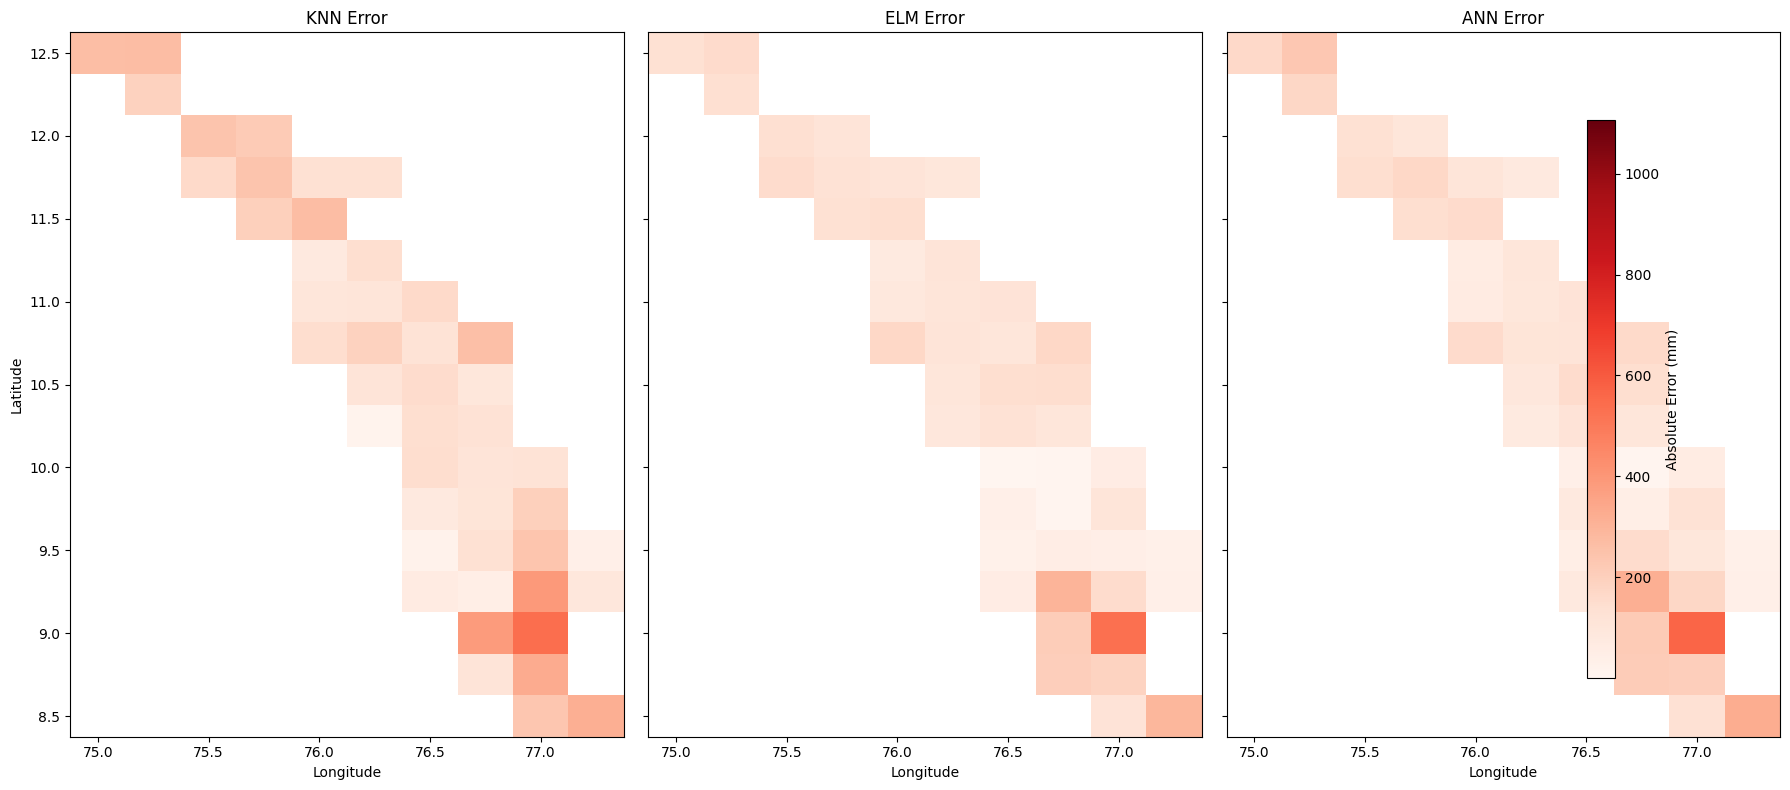


--- Spatial Accuracy Metrics for 2018 ---
  KNN:
    - Mean Absolute Error: 77.49 mm (17.9%)
    - Max Absolute Error:  374.74 mm
  ELM:
    - Mean Absolute Error: 63.32 mm (14.6%)
    - Max Absolute Error:  278.43 mm
  ANN:
    - Mean Absolute Error: 58.37 mm (13.5%)
    - Max Absolute Error:  255.78 mm


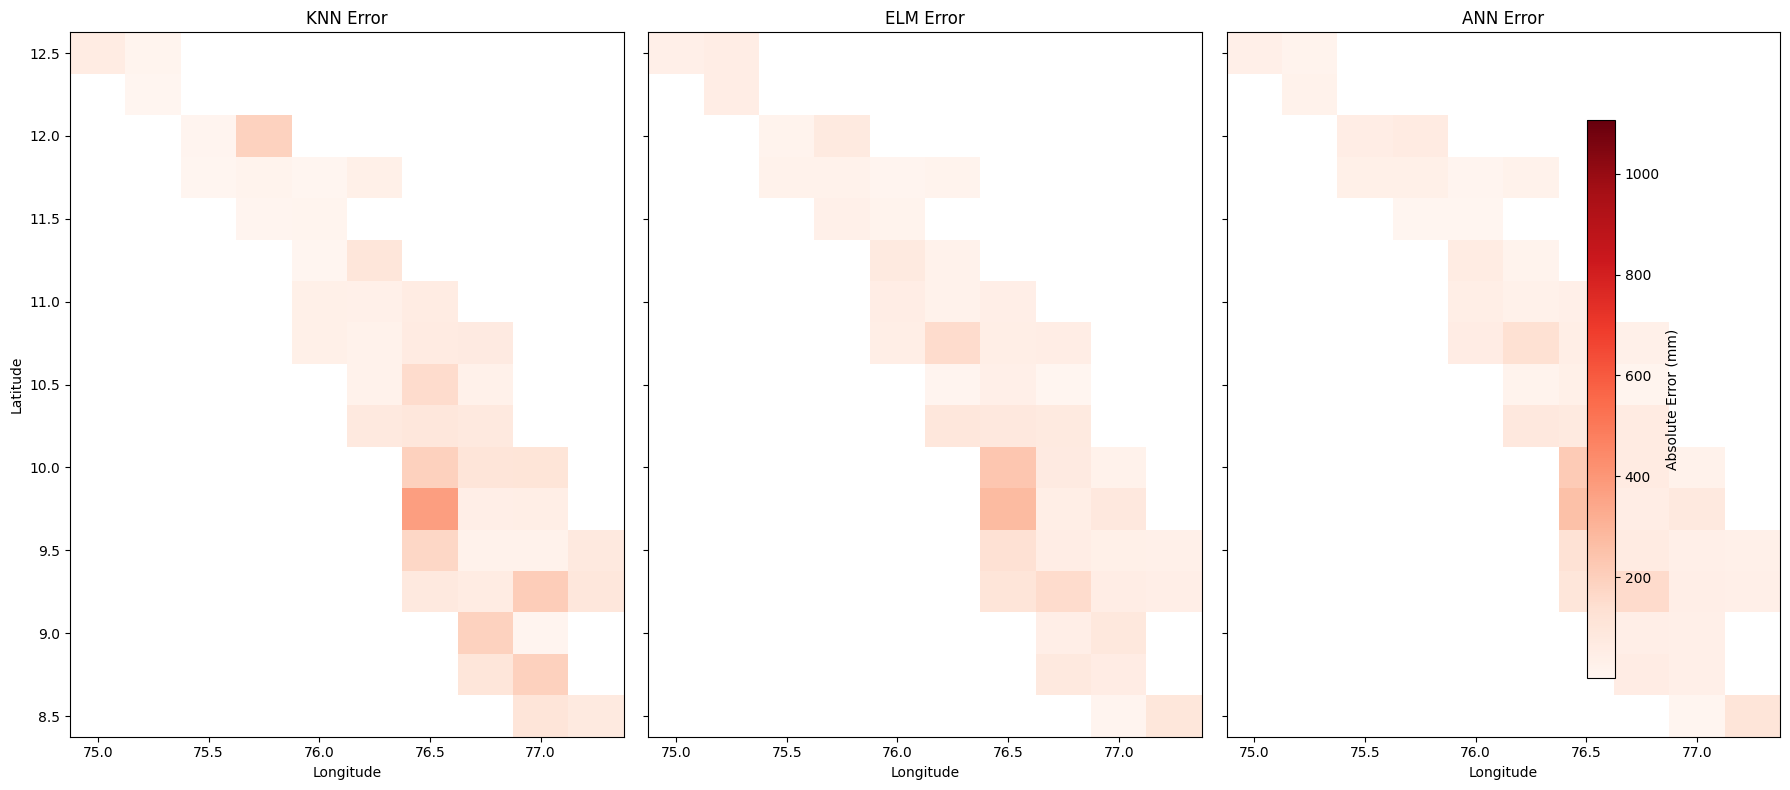


--- Spatial Accuracy Metrics for 2019 ---
  KNN:
    - Mean Absolute Error: 120.86 mm (21.0%)
    - Max Absolute Error:  312.97 mm
  ELM:
    - Mean Absolute Error: 95.96 mm (16.7%)
    - Max Absolute Error:  288.96 mm
  ANN:
    - Mean Absolute Error: 91.10 mm (15.8%)
    - Max Absolute Error:  273.57 mm


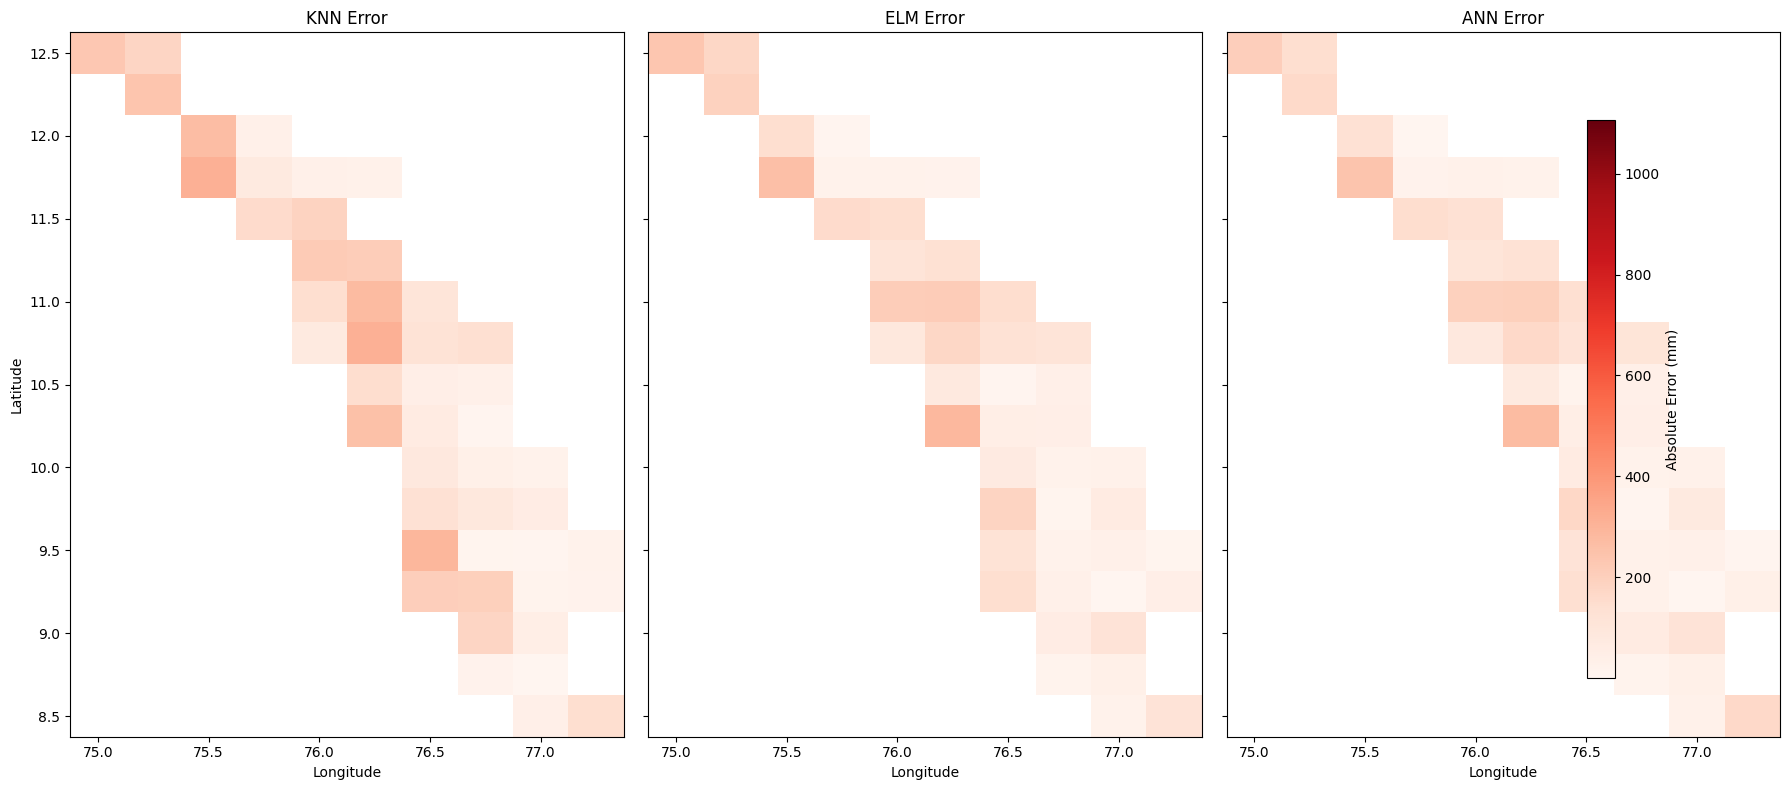


--- Spatial Accuracy Metrics for 2020 ---
  KNN:
    - Mean Absolute Error: 137.92 mm (38.1%)
    - Max Absolute Error:  388.85 mm
  ELM:
    - Mean Absolute Error: 109.28 mm (30.2%)
    - Max Absolute Error:  228.20 mm
  ANN:
    - Mean Absolute Error: 105.74 mm (29.2%)
    - Max Absolute Error:  225.11 mm


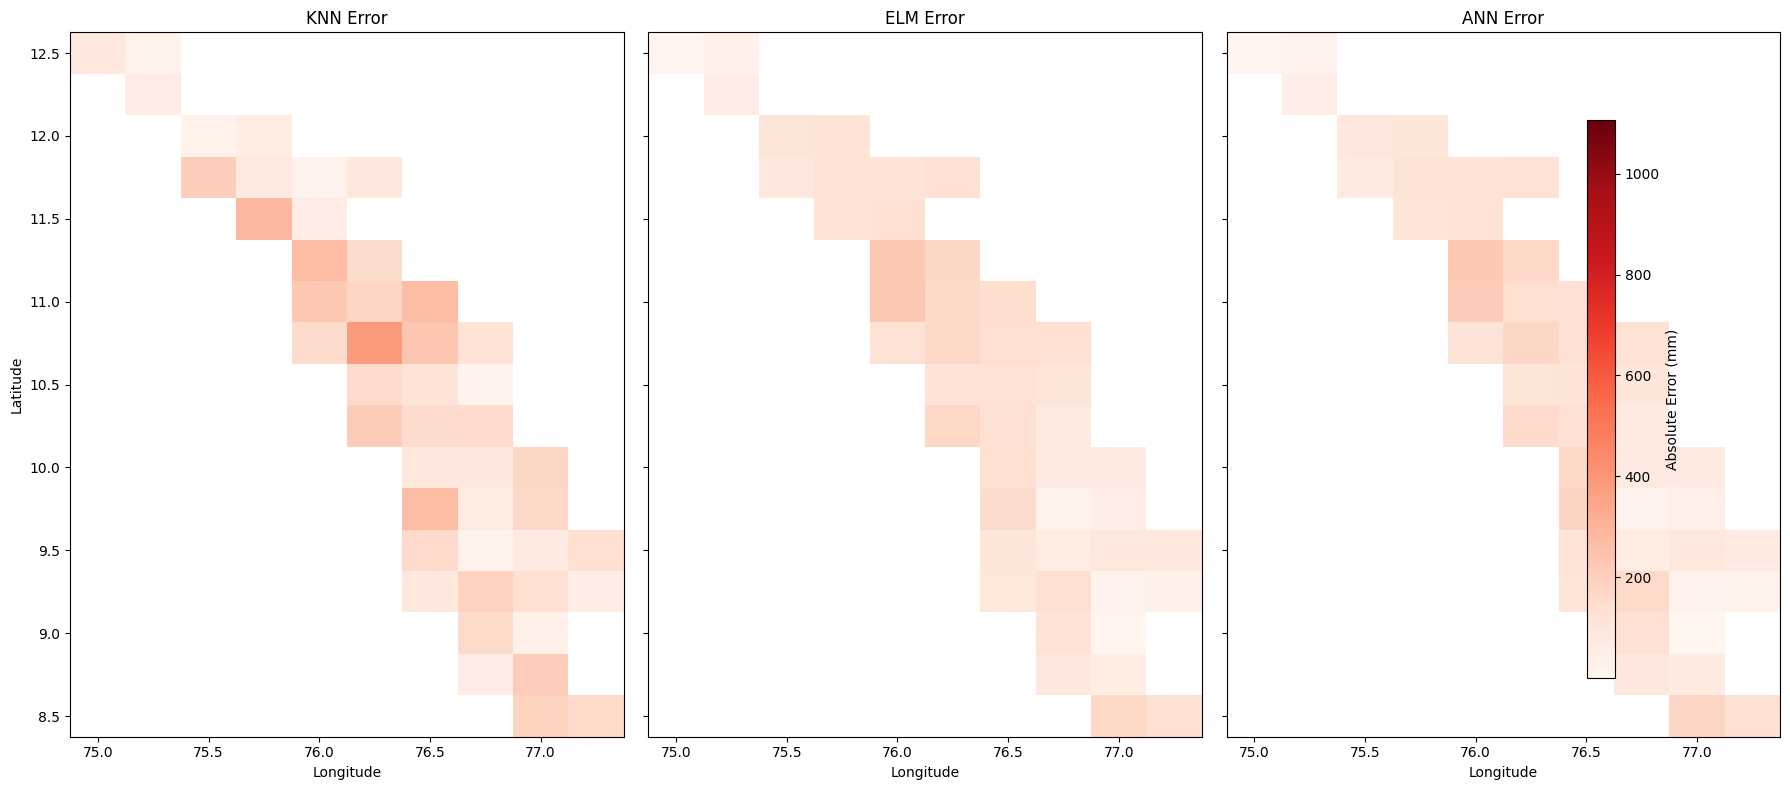


--- Spatial Accuracy Metrics for 2021 ---
  KNN:
    - Mean Absolute Error: 425.43 mm (43.0%)
    - Max Absolute Error:  1082.54 mm
  ELM:
    - Mean Absolute Error: 378.90 mm (38.3%)
    - Max Absolute Error:  1104.26 mm
  ANN:
    - Mean Absolute Error: 380.19 mm (38.4%)
    - Max Absolute Error:  1106.28 mm


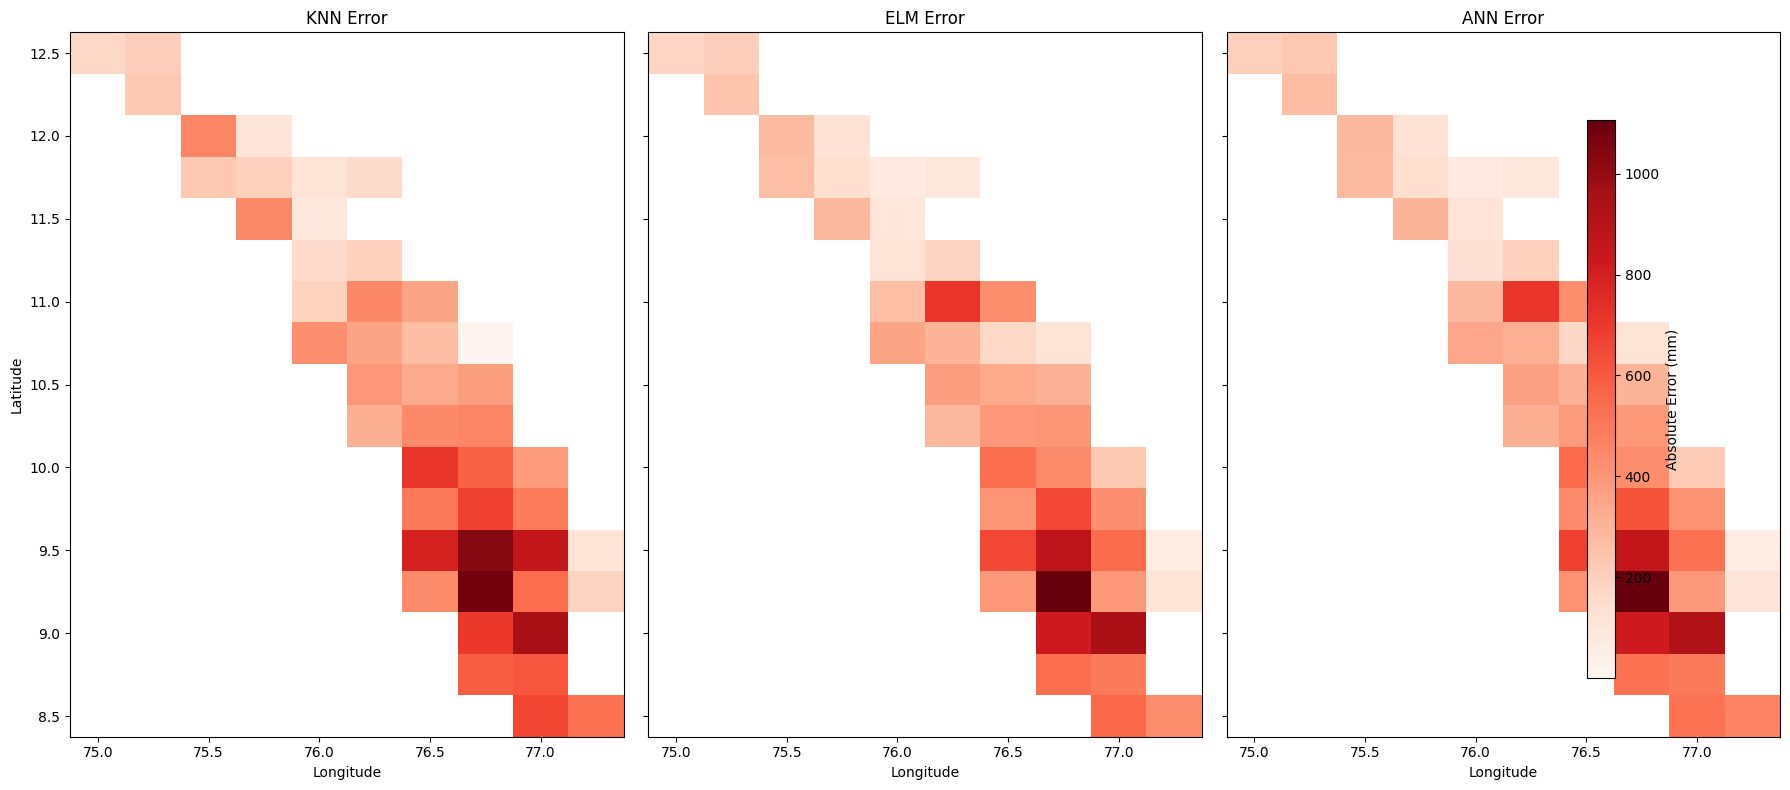


--- Spatial Accuracy Metrics for 2022 ---
  KNN:
    - Mean Absolute Error: 112.12 mm (23.0%)
    - Max Absolute Error:  357.05 mm
  ELM:
    - Mean Absolute Error: 89.58 mm (18.3%)
    - Max Absolute Error:  199.38 mm
  ANN:
    - Mean Absolute Error: 72.08 mm (14.8%)
    - Max Absolute Error:  190.64 mm


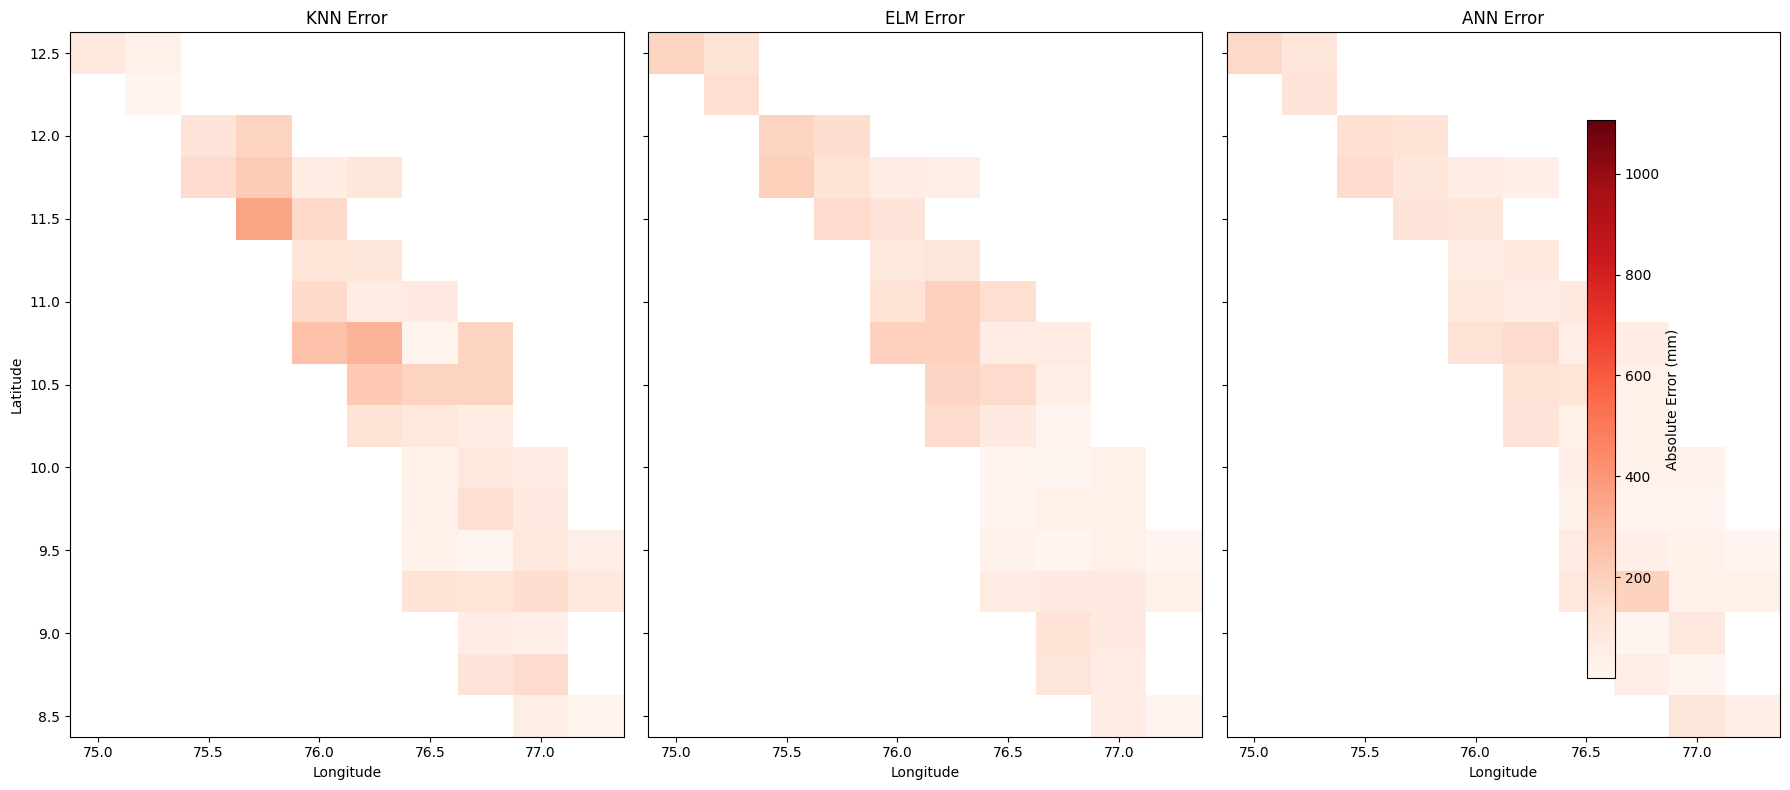

In [ ]:
# Visualization functions: time-series, spatial maps, and spatial error plots
def visualize_results(test_meta_df, y_true_orig, y_pred_knn, y_pred_elm, y_pred_ann):
    """Create time-series visualizations with correct temporal alignment."""
    plot_df = test_meta_df.copy()
    plot_df['ACTUAL'] = y_true_orig
    plot_df['KNN_PRED'] = y_pred_knn
    plot_df['ELM_PRED'] = y_pred_elm
    plot_df['ANN_PRED'] = y_pred_ann
    # Predictions correspond to YEAR - 1 (they were made using data up to previous year)
    plot_df['PRED_YEAR'] = plot_df['YEAR'] - 1
    actual_yearly = plot_df.groupby('YEAR')['ACTUAL'].mean()
    knn_yearly = plot_df.groupby('PRED_YEAR')['KNN_PRED'].mean()
    elm_yearly = plot_df.groupby('PRED_YEAR')['ELM_PRED'].mean()
    ann_yearly = plot_df.groupby('PRED_YEAR')['ANN_PRED'].mean()
    plt.figure(figsize=(14, 6))
    plt.plot(actual_yearly.index, actual_yearly.values, label='Actual', marker='o', linewidth=2)
    plt.plot(knn_yearly.index, knn_yearly.values, label='KNN', linestyle='--')
    plt.plot(elm_yearly.index, elm_yearly.values, label='ELM', linestyle='-.')
    plt.plot(ann_yearly.index, ann_yearly.values, label='ANN', linestyle=':')
    plt.title('All Models: Season Actual vs. Predicted Monsoon Rainfall (OND)', fontsize=18)
    plt.xlabel('Year', fontsize=14)
    plt.ylabel('Rainfall (mm)', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def visualize_spatial_predictions(test_meta_df, y_true, y_pred_knn, y_pred_elm, y_pred_ann, kerala_shape):
    """Spatial rainfall maps with temporal alignment:
    - ACTUAL at YEAR
    - Predictions at YEAR - 1
    """
    results_df = test_meta_df.copy()
    results_df['ACTUAL'] = y_true
    results_df['KNN'] = y_pred_knn
    results_df['ELM'] = y_pred_elm
    results_df['ANN'] = y_pred_ann
    results_df['PRED_YEAR'] = results_df['YEAR'] - 1
    models_pred = ['KNN', 'ELM', 'ANN']
    # compute global color limits
    all_values = np.concatenate([results_df['ACTUAL'].values.flatten(), results_df['KNN'].values.flatten(), results_df['ELM'].values.flatten(), results_df['ANN'].values.flatten()])
    global_vmin = np.nanmin(all_values)
    global_vmax = np.nanmax(all_values)
    norm = Normalize(vmin=global_vmin, vmax=global_vmax)
    years = sorted(results_df['YEAR'].unique())
    for year in years:
        actual_df = results_df[results_df['YEAR'] == year]
        pred_df = results_df[results_df['PRED_YEAR'] == year]
        if actual_df.empty or pred_df.empty:
            continue
        fig, axes = plt.subplots(1, 4, figsize=(20, 6), sharey=True)
        fig.suptitle(f'Spatial Rainfall Patterns – OND {year}', fontsize=20)
        pivot = actual_df.pivot(index='LATITUDE', columns='LONGITUDE', values='ACTUAL')
        lats = pivot.index.values
        lons = pivot.columns.values
        data = pivot.values
        masked_data = np.full_like(data, np.nan)
        for iy, lat in enumerate(lats):
            for ix, lon in enumerate(lons):
                cell = box(lon - 0.125, lat - 0.125, lon + 0.125, lat + 0.125)
                if kerala_shape.geometry.iloc[0].contains(cell.centroid):
                    masked_data[iy, ix] = data[iy, ix]
        mesh = axes[0].pcolormesh(lons, lats, masked_data, cmap='Spectral_r', norm=norm, shading='auto')
        kerala_shape.boundary.plot(ax=axes[0], color='black', linewidth=1.2)
        axes[0].set_title('ACTUAL')
        for i, model in enumerate(models_pred, start=1):
            pivot = pred_df.pivot(index='LATITUDE', columns='LONGITUDE', values=model)
            data = pivot.values
            masked_data = np.full_like(data, np.nan)
            for iy, lat in enumerate(lats):
                for ix, lon in enumerate(lons):
                    cell = box(lon - 0.125, lat - 0.125, lon + 0.125, lat + 0.125)
                    if kerala_shape.geometry.iloc[0].contains(cell.centroid):
                        masked_data[iy, ix] = data[iy, ix]
            axes[i].pcolormesh(lons, lats, masked_data, cmap='Spectral_r', norm=norm, shading='auto')
            kerala_shape.boundary.plot(ax=axes[i], color='black', linewidth=1.2)
            axes[i].set_title(model)
        sm = plt.cm.ScalarMappable(cmap='Spectral_r', norm=norm)
        sm.set_array([])
        fig.colorbar(sm, ax=axes, fraction=0.03, pad=0.02)
        plt.tight_layout()
        plt.show()

def visualize_spatial_error(test_meta_df, y_true, y_pred_knn, y_pred_elm, y_pred_ann):
    results_df = test_meta_df.copy()
    results_df['ACTUAL'] = y_true
    results_df['KNN_PRED'] = y_pred_knn
    results_df['ELM_PRED'] = y_pred_elm
    results_df['ANN_PRED'] = y_pred_ann
    results_df['PRED_YEAR'] = results_df['YEAR'] - 1
    actual_df = results_df[['YEAR', 'LATITUDE', 'LONGITUDE', 'ACTUAL']]
    pred_df = results_df[['PRED_YEAR', 'LATITUDE', 'LONGITUDE', 'KNN_PRED', 'ELM_PRED', 'ANN_PRED']].rename(columns={'PRED_YEAR': 'YEAR'})
    merged_df = pd.merge(actual_df, pred_df, on=['YEAR', 'LATITUDE', 'LONGITUDE'], how='inner')
    merged_df['KNN_Error'] = np.abs(merged_df['ACTUAL'] - merged_df['KNN_PRED'])
    merged_df['ELM_Error'] = np.abs(merged_df['ACTUAL'] - merged_df['ELM_PRED'])
    merged_df['ANN_Error'] = np.abs(merged_df['ACTUAL'] - merged_df['ANN_PRED'])
    test_years = sorted(merged_df['YEAR'].unique())
    model_errors = ['KNN_Error', 'ELM_Error', 'ANN_Error']
    vmin = merged_df[model_errors].min().min()
    vmax = merged_df[model_errors].max().max()
    norm = Normalize(vmin=vmin, vmax=vmax)
    for year in test_years:
        year_df = merged_df[merged_df['YEAR'] == year]
        print(f"\n--- Spatial Accuracy Metrics for {year} ---")
        mean_actual_for_year = year_df['ACTUAL'].mean()
        for model in ['KNN', 'ELM', 'ANN']:
            error_col = f'{model}_Error'
            mean_error = year_df[error_col].mean()
            max_error = year_df[error_col].max()
            mae_p = 100 * mean_error / mean_actual_for_year if mean_actual_for_year > 0 else 0
            print(f"  {model}:")
            print(f"    - Mean Absolute Error: {mean_error:.2f} mm ({mae_p:.1f}%)")
            print(f"    - Max Absolute Error:  {max_error:.2f} mm")
        fig, axes = plt.subplots(1, 3, figsize=(18, 8), sharey=True)
        mesh = None
        for i, model_error in enumerate(model_errors):
            ax = axes[i]
            try:
                pivot_df = year_df.pivot(index='LATITUDE', columns='LONGITUDE', values=model_error)
                lons = pivot_df.columns
                lats = pivot_df.index
                data = pivot_df.values
                mesh = ax.pcolormesh(lons, lats, data, cmap='Reds', norm=norm)
                ax.set_title(model_error.replace('_', ' '))
                ax.set_xlabel('Longitude')
                if i == 0:
                    ax.set_ylabel('Latitude')
            except Exception as e:
                ax.text(0.5, 0.5, f'Could not plot:\n{e}', ha='center', va='center')
                ax.set_title(model_error.replace('_', ' '))
        if mesh is not None:
            fig.colorbar(mesh, ax=axes, orientation='vertical', label='Absolute Error (mm)', fraction=0.02, pad=0.04)
        plt.tight_layout()
        plt.show()

# Load Kerala shape and run visualizations
shp_path = r"ne_10m_admin_1_states_provinces\ne_10m_admin_1_states_provinces.shp"
india_states = gpd.read_file(shp_path)
kerala_shape = india_states[(india_states["admin"] == "India") & (india_states["name"] == "Kerala")].to_crs(epsg=4326)
print("Generating visualizations...")
visualize_results(y_test_meta, y_true_orig, y_pred_knn_orig, y_pred_elm_orig, y_pred_ann_orig)
visualize_spatial_predictions(y_test_meta, y_true_orig, y_pred_knn_orig, y_pred_elm_orig, y_pred_ann_orig, kerala_shape)
visualize_spatial_error(y_test_meta, y_true_orig, y_pred_knn_orig, y_pred_elm_orig, y_pred_ann_orig)